# **Hotel 'A' -Train Dataset**


### **Data Exploration**

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Reading the CSV files
Historical_train = pd.read_csv('/content/drive/MyDrive/Hotel Revenue Prediction GCW/Hotel-A-train.csv')

In [4]:
#Load dataset
Historical_train

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,07/01/2015,07/02/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes,10,218
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,07/01/2015,07/02/2015,...,BB,No,No,Refundable,Online,Yes,Check-Out,No,0,185
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,07/02/2015,07/06/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,119
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,07/02/2015,07/03/2015,...,BB,No,No,Refundable,Agent,Yes,Check-Out,Yes,5,144
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,07/03/2015,07/04/2015,...,BB,No,No,No Deposit,Direct,No,Check-Out,Yes,10,242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27494,15645505,F,49,African American,Mid-School,<25K,West,City Hotel,8/31/2016,09/01/2016,...,HB,Yes,Yes,No Deposit,Online,Yes,Check-Out,Yes,10,100
27495,56414525,F,49,Asian American,College,25K --50K,South,Airport Hotels,8/31/2016,09/01/2016,...,BB,No,No,Refundable,Agent,Yes,No-Show,Yes,40,194
27496,52023375,F,49,Latino,High-School,50K -- 100K,South,Airport Hotels,09/01/2016,09/02/2016,...,HB,No,No,No Deposit,Direct,Yes,Check-Out,Yes,5,202
27497,98041387,M,65,African American,College,25K --50K,South,Airport Hotels,8/31/2016,09/01/2016,...,FB,No,No,No Deposit,Online,No,Canceled,Yes,20,157


In [5]:
#No. of rows and columns in dataset
print(Historical_train.shape)

(27499, 24)


In [6]:
#Data types of each column in  dataset
print(Historical_train.dtypes)

Reservation-id             int64
Gender                    object
Age                        int64
Ethnicity                 object
Educational_Level         object
Income                    object
Country_region            object
Hotel_Type                object
Expected_checkin          object
Expected_checkout         object
Booking_date              object
Adults                     int64
Children                   int64
Babies                     int64
Meal_Type                 object
Visted_Previously         object
Previous_Cancellations    object
Deposit_type              object
Booking_channel           object
Required_Car_Parking      object
Reservation_Status        object
Use_Promotion             object
Discount_Rate              int64
Room_Rate                  int64
dtype: object


In [7]:
#identify the missing data
print(Historical_train.isnull().sum())

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Reservation_Status        0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64


In [8]:
#Descriptive statistics for numeric attributes
Historical_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Reservation-id,27499.0,5.016461e+07,2.886911e+07,3154.0,25239432.0,50149955.0,75182883.0,99999005.0
Age,27499.0,4.397745e+01,1.530315e+01,18.0,31.0,44.0,57.0,70.0
Adults,27499.0,2.333576e+00,1.176526e+00,1.0,2.0,2.0,3.0,5.0
Children,27499.0,1.743882e+00,7.219721e-01,1.0,1.0,2.0,2.0,3.0
Babies,27499.0,3.515401e-01,5.733259e-01,0.0,0.0,0.0,1.0,2.0
Discount_Rate,27499.0,1.249518e+01,1.120604e+01,0.0,5.0,10.0,20.0,40.0
Room_Rate,27499.0,1.751365e+02,4.387709e+01,100.0,137.0,175.0,214.0,250.0


In [9]:
#Descriptive statistics for non-numeric attributes
Historical_train.describe(include=['object']).T

,count,unique,top,freq
Gender,27499,2,F,13799
Ethnicity,27499,4,African American,6965
Educational_Level,27499,4,College,11052
Income,27499,4,50K -- 100K,7936
Country_region,27499,4,South,10917
Hotel_Type,27499,3,Airport Hotels,9258
Expected_checkin,27499,901,02/09/2016,145
Expected_checkout,27499,929,3/14/2016,91
Booking_date,27499,1133,10/19/2015,232
Meal_Type,27499,3,BB,14224


In [10]:
from os import dup
# whole‑row duplicates
dup_row = Historical_train.duplicated(keep=False)
duplicates = Historical_train[dup_row]
print("Total duplicate rows:", dup_row.sum())


Total duplicate rows: 0


In [11]:
# Duplicates on a particular key
dup_id = Historical_train['Reservation-id'].duplicated(keep=False)
print("Rows sharing the same Reservation ID:", dup_id.sum())
dup_by_id = Historical_train[dup_id]

# Summary counts per key to see how many times each value occurs
counts = Historical_train['Reservation-id'].value_counts()
counts[counts>1]

Rows sharing the same Reservation ID: 8


,count
Reservation-id,
95504255,2
55371044,2
91130744,2
76641511,2


In [12]:
#Identifying unique values
unique_values_train = Historical_train.apply(pd.Series.unique)
print(unique_values_train)

Reservation-id            [39428300, 77491756, 73747291, 67301739, 77222...
Gender                                                               [F, M]
Age                       [40, 49, 42, 25, 62, 34, 53, 59, 21, 69, 52, 5...
Ethnicity                 [Latino, caucasian, African American, Asian Am...
Educational_Level                  [Grad, Mid-School, College, High-School]
Income                                [<25K, 50K -- 100K, >100K, 25K --50K]
Country_region                                   [North, East, South, West]
Hotel_Type                             [City Hotel, Airport Hotels, Resort]
Expected_checkin          [07/01/2015, 07/02/2015, 07/03/2015, 05/06/201...
Expected_checkout         [07/02/2015, 07/06/2015, 07/03/2015, 07/04/201...
Booking_date              [5/21/2015, 5/26/2015, 6/29/2015, 6/20/2015, 0...
Adults                                                      [2, 3, 4, 1, 5]
Children                                                          [2, 3, 1]
Babies      

## **Before Cleaning- Exploratory Data Analysis**

### **Univariate Analysis**

In [13]:
Historical_train_before = Historical_train.copy()

In [14]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

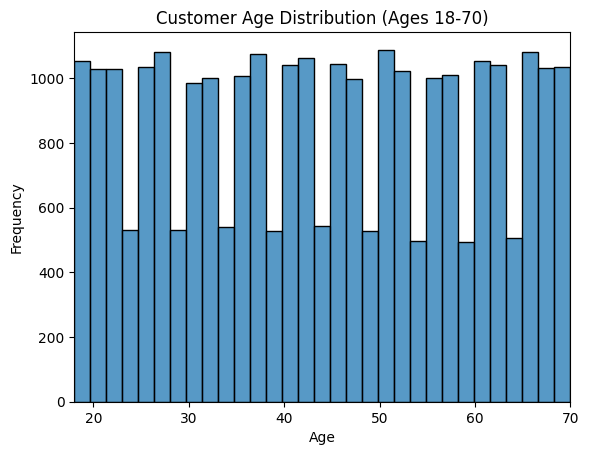

In [15]:
# Age Histogram
plt.figure()
sns.histplot(data=Historical_train_before, x="Age")
plt.title("Customer Age Distribution (Ages 18-70)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xlim(18, 70) # Set x-axis limits to 18-70
plt.show()

In [16]:

# Convert 'Expected_checkin', 'Expected_checkout' and 'Booking_date' to datetime objects
Historical_train_before['Expected_checkin'] = pd.to_datetime(Historical_train_before['Expected_checkin'])
Historical_train_before['Expected_checkout'] = pd.to_datetime(Historical_train_before['Expected_checkout'])
Historical_train_before['Booking_date'] = pd.to_datetime(Historical_train_before['Booking_date'])


In [17]:
# Calculate Lead_Days
Historical_train_before['Lead_Days'] = (Historical_train_before['Expected_checkin'] - Historical_train_before['Booking_date']).dt.days

# Display the first few rows with the new 'Lead_Days' column
display(Historical_train_before[['Expected_checkin', 'Booking_date', 'Lead_Days']].head())

,Expected_checkin,Booking_date,Lead_Days
0,2015-07-01,2015-05-21,41
1,2015-07-01,2015-05-26,36
2,2015-07-02,2015-06-29,3
3,2015-07-02,2015-06-20,12
4,2015-07-03,2015-06-20,13


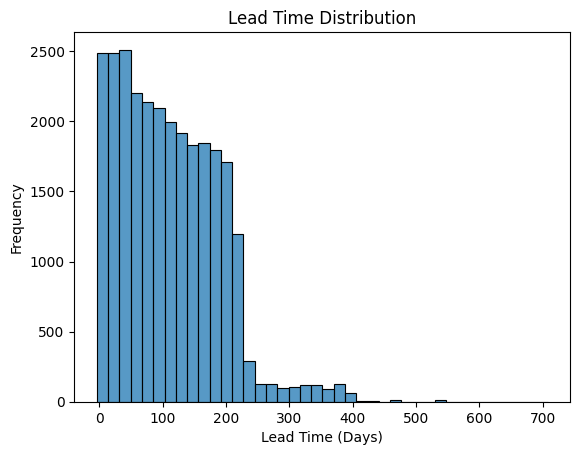

In [18]:
# Lead Time Histogram
plt.figure()
sns.histplot(data=Historical_train_before, x="Lead_Days", bins=40)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

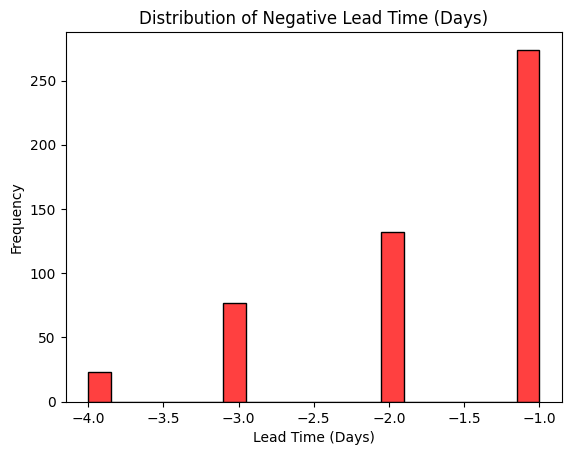

In [19]:
# Filter for negative Lead_Days
negative_lead_days = Historical_train_before[Historical_train_before['Lead_Days'] < 0]

# Histogram for negative Lead_Days
plt.figure()
sns.histplot(data=negative_lead_days, x="Lead_Days", bins=20, color='red')
plt.title("Distribution of Negative Lead Time (Days)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

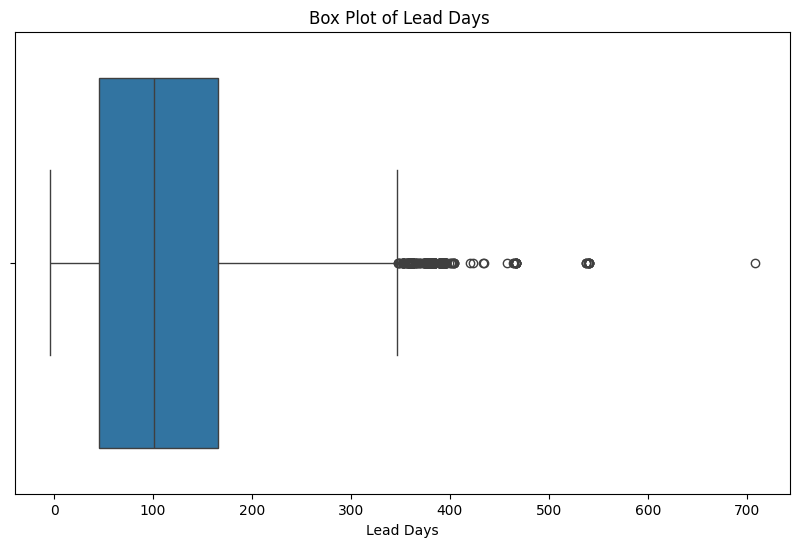

In [20]:
# Box plot to identify outliers in Lead_Days
plt.figure(figsize=(10, 6))
sns.boxplot(x=Historical_train_before['Lead_Days'])
plt.title('Box Plot of Lead Days ')
plt.xlabel('Lead Days')
plt.show()

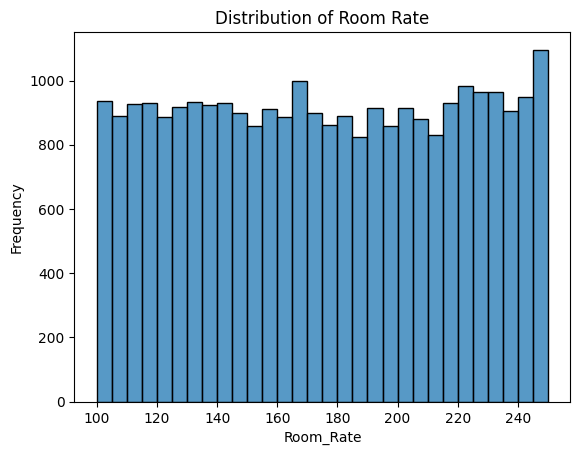

In [21]:
# Distribution of Room Rate
plt.figure()
sns.histplot(data=Historical_train_before, x="Room_Rate", bins=30)
plt.title("Distribution of Room Rate")
plt.xlabel("Room_Rate")
plt.ylabel("Frequency")
plt.show()

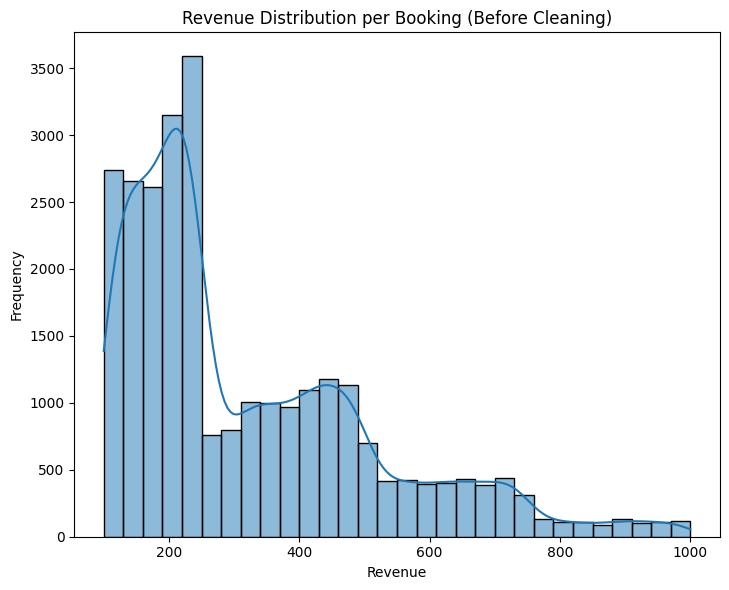

In [22]:
# Calculate stay_nights for Historical_train_before
Historical_train_before['Expected_checkin'] = pd.to_datetime(Historical_train_before['Expected_checkin'])
Historical_train_before['Expected_checkout'] = pd.to_datetime(Historical_train_before['Expected_checkout'])
Historical_train_before['stay_nights'] = (Historical_train_before['Expected_checkout'] - Historical_train_before['Expected_checkin']).dt.days

# Calculate Revenue for Historical_train_before
Historical_train_before['Revenue'] = Historical_train_before['stay_nights'] * Historical_train_before['Room_Rate']

plt.figure(figsize=(14, 6))

# Plot for Original Data (Before Cleaning)
plt.subplot(1, 2, 1)
sns.histplot(Historical_train_before['Revenue'], bins=30, kde=True)
plt.title("Revenue Distribution per Booking (Before Cleaning)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

/tmp/ipykernel_12567/3746000927.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Historical_train_before, x="Discount_Rate", palette="plasma")
/tmp/ipykernel_12567/3746000927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Historical_train_before, x="Room_Rate", palette="viridis")


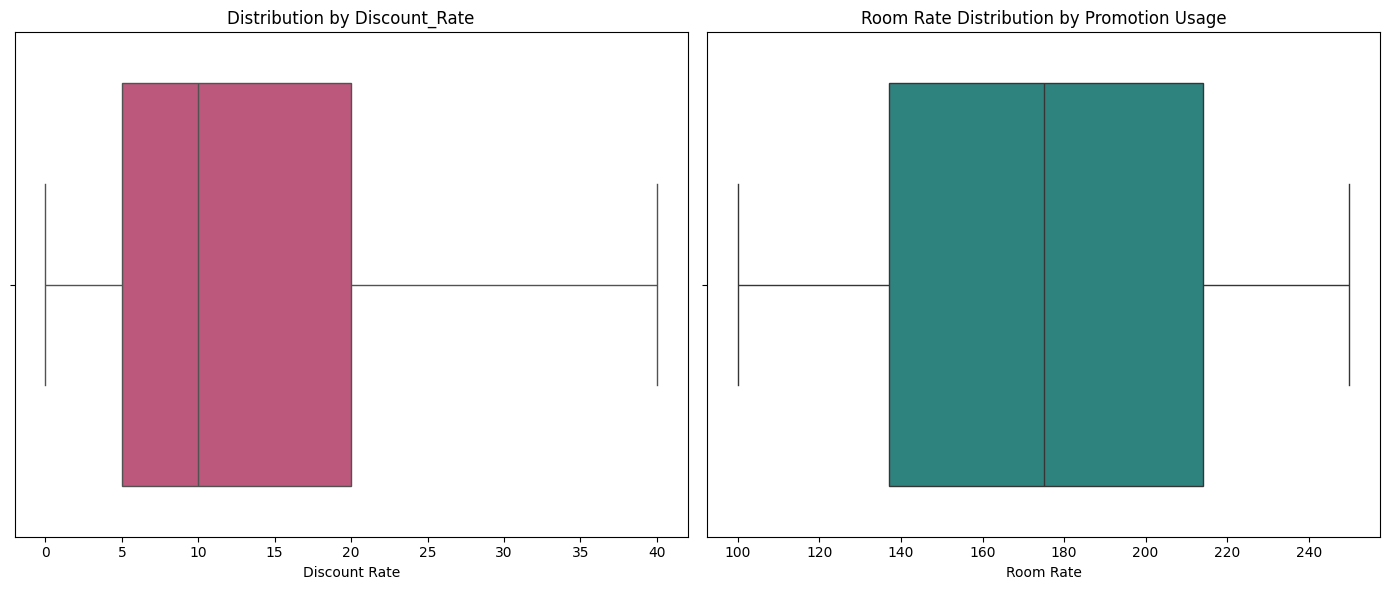

In [23]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # First subplot for Discount_Rate
sns.boxplot(data=Historical_train_before, x="Discount_Rate", palette="plasma")
plt.title("Distribution by Discount_Rate")
plt.xlabel("Discount Rate")

plt.subplot(1, 2, 2) # Second subplot for Room_Rate
sns.boxplot(data=Historical_train_before, x="Room_Rate", palette="viridis")
plt.title("Room Rate Distribution by Promotion Usage")
plt.xlabel("Room Rate")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Customer Region Distribution')

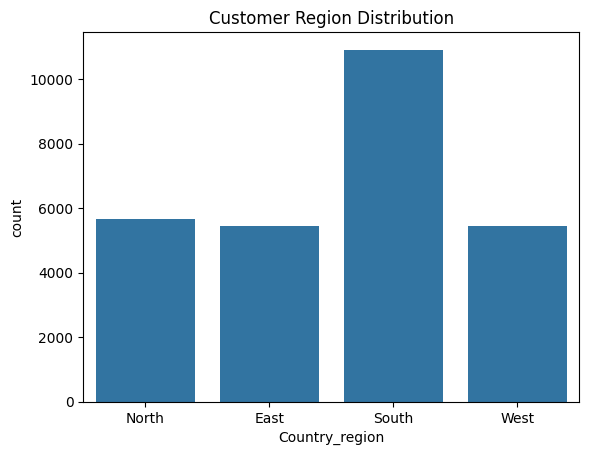

In [24]:
sns.countplot(data=Historical_train_before, x="Country_region")
plt.title("Customer Region Distribution")

### **Bivariate analysis**

In [25]:
# Revenue Loss by Hotel Type
loss_data = Historical_train_before[
    Historical_train_before['Reservation_Status'].isin(['Canceled', 'No-Show'])
]

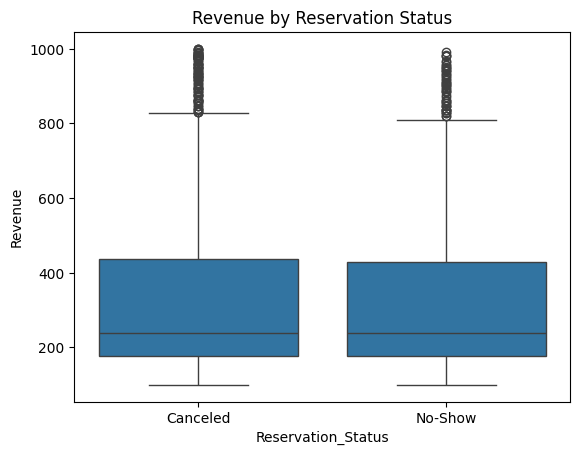

In [26]:
# Revenue Loss by Reservation Status
sns.boxplot(x='Reservation_Status', y='Revenue', data=loss_data)
plt.title("Revenue by Reservation Status")
plt.show()

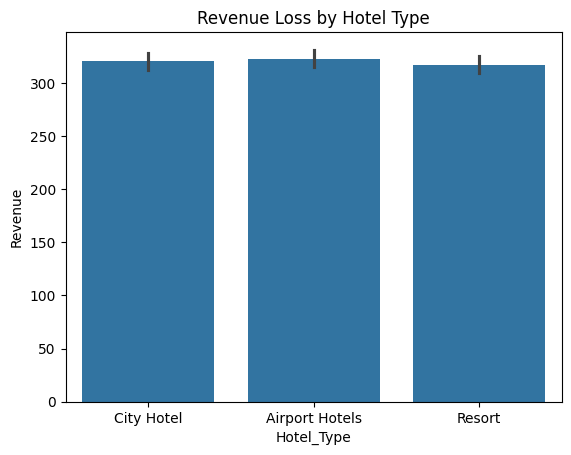

In [27]:
# Revenue Loss by Hotel Type
loss_data = Historical_train_before[
    Historical_train_before['Reservation_Status'].isin(['Canceled', 'No-Show'])
]

sns.barplot(x='Hotel_Type', y='Revenue', data=loss_data)
plt.title("Revenue Loss by Hotel Type")
plt.show()

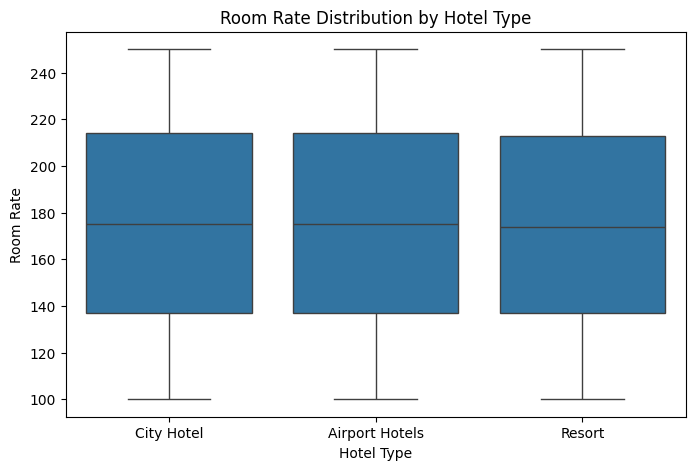

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=Historical_train_before, x="Hotel_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Room Rate")
plt.show()

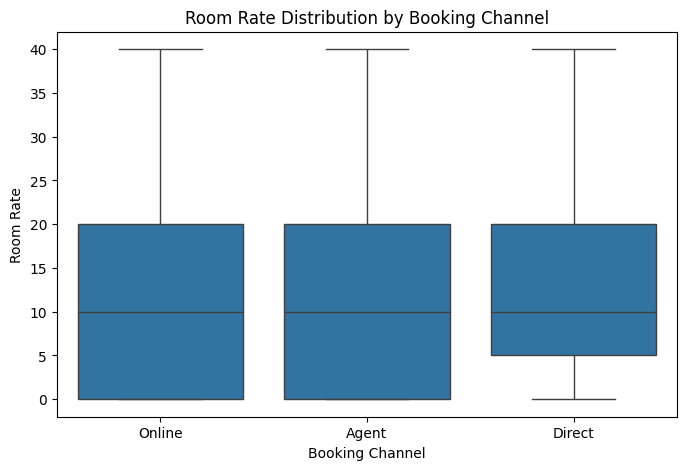

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(data=Historical_train_before, x="Booking_channel", y="Discount_Rate")
plt.title("Room Rate Distribution by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Room Rate")
plt.show()

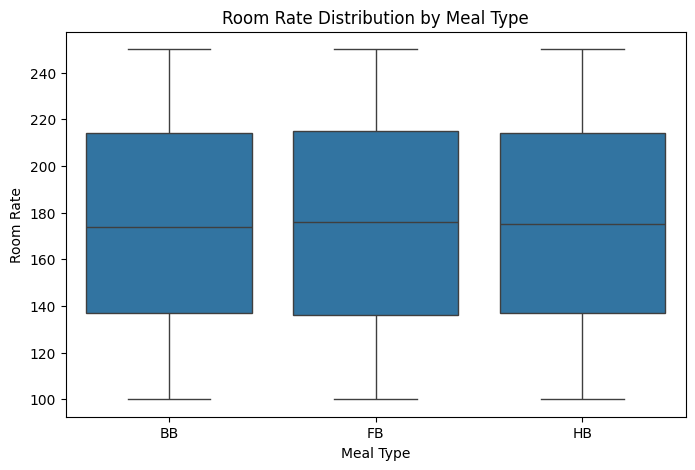

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=Historical_train_before, x="Meal_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Meal Type")
plt.xlabel("Meal Type")
plt.ylabel("Room Rate")
plt.show()

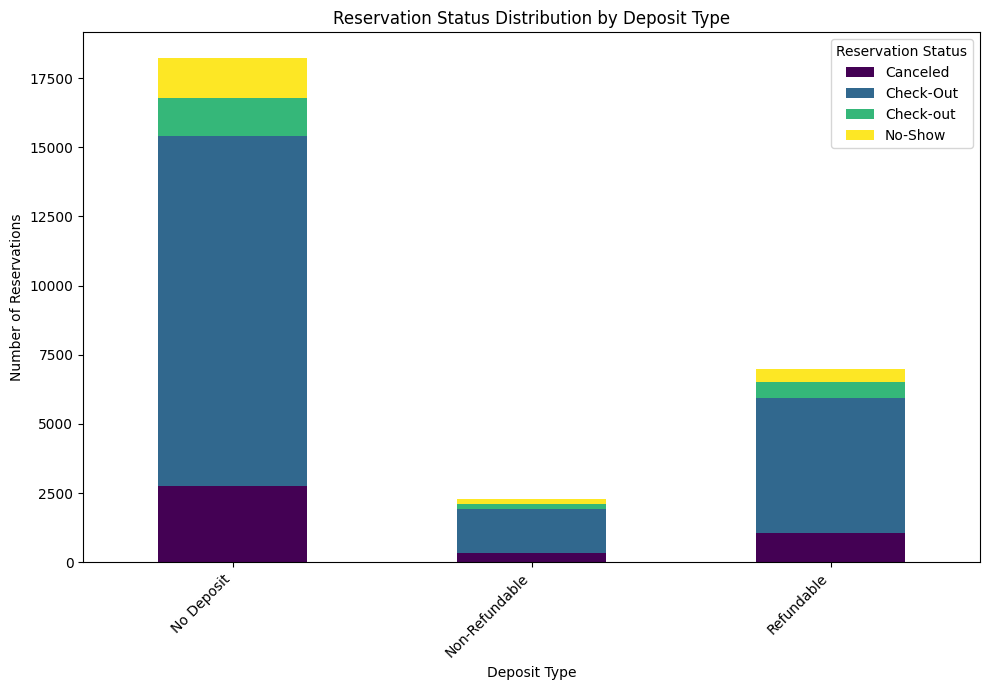

In [31]:
# Group by Deposit_type and Reservation_Status and count occurrences
deposit_status_counts = Historical_train_before.groupby(['Deposit_type', 'Reservation_Status']).size().unstack(fill_value=0)

# Create a stacked bar chart
plt.figure(figsize=(10, 7))
deposit_status_counts.plot(kind='bar', stacked=True, cmap='viridis', ax=plt.gca())
plt.title('Reservation Status Distribution by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Reservations')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reservation Status')
plt.tight_layout()
plt.show()

### **Multivariate Analysis**

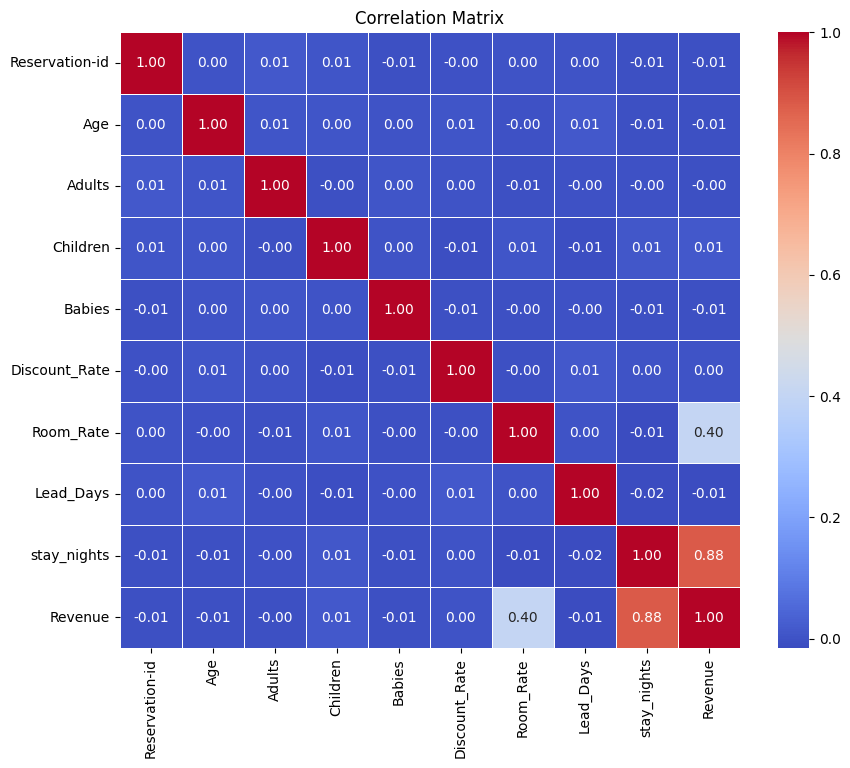

In [32]:
# Correlation Matrix
correlation_matrix = Historical_train_before.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

## **Data Cleaning**

In [33]:
import pandas as pd
import numpy as np

In [34]:
total_rows = Historical_train.shape[0]
num_duplicate_id_rows = dup_id.sum()
percentage_duplicate_ids = (num_duplicate_id_rows / total_rows) * 100

print(f"Total Number of rows: {total_rows}")
print(f"Number of rows with duplicate Reservation IDs: {num_duplicate_id_rows}")
print(f"Percentage of rows with duplicate Reservation IDs: {percentage_duplicate_ids:.2f}%")

Total Number of rows: 27499
Number of rows with duplicate Reservation IDs: 8
Percentage of rows with duplicate Reservation IDs: 0.03%


In [35]:
# Drop rows with duplicate Reservation IDs
Historical_train = Historical_train[~dup_id]

print(f"Shape of Historical_train after dropping duplicate Reservation IDs: {Historical_train.shape}")

Shape of Historical_train after dropping duplicate Reservation IDs: (27491, 24)


In [36]:
# Display counts before standardization
print(Historical_train ['Reservation_Status'].value_counts())

Reservation_Status
Check-Out    19087
Canceled      4134
Check-out     2148
No-Show       2122
Name: count, dtype: int64


In [37]:
# Change data types
# Convert 'Expected_checkin', 'Expected_checkout' and 'Booking_date' to datetime objects
Historical_train['Expected_checkin'] = pd.to_datetime(Historical_train['Expected_checkin'])
Historical_train['Expected_checkout'] = pd.to_datetime(Historical_train['Expected_checkout'])
Historical_train['Booking_date'] = pd.to_datetime(Historical_train['Booking_date'])

/tmp/ipykernel_12567/1179670216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Historical_train['Expected_checkin'] = pd.to_datetime(Historical_train['Expected_checkin'])
/tmp/ipykernel_12567/1179670216.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Historical_train['Expected_checkout'] = pd.to_datetime(Historical_train['Expected_checkout'])
/tmp/ipykernel_12567/1179670216.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [38]:
# Standardize column names for easier feature work
Historical_train = Historical_train.rename(columns={'Reservation-id':'Reservation_id'})

In [39]:
# Calculate stay_nights
Historical_train['stay_nights'] = (Historical_train['Expected_checkout'] - Historical_train['Expected_checkin']).dt.days

# Calculate lead_time_days
Historical_train['Lead_Days'] = (Historical_train['Expected_checkin'] - Historical_train['Booking_date']).dt.days

# Calculate revenue
Historical_train['Revenue'] = Historical_train['stay_nights'] * Historical_train['Room_Rate']


In [40]:
# Impute negative 'Lead_Days' values to 0
Historical_train['Lead_Days'] = Historical_train['Lead_Days'].apply(lambda x: max(x, 0))

# Display descriptive statistics for 'Lead_Days' to confirm imputation
print(Historical_train['Lead_Days'].describe())

count    27491.000000
mean       109.941217
std         78.003382
min          0.000000
25%         45.000000
50%        101.000000
75%        166.000000
max        708.000000
Name: Lead_Days, dtype: float64


In [41]:
# Date parts for seasonality

Historical_train['Expected_checkin_year'] = Historical_train['Expected_checkin'].dt.year
Historical_train['Expected_checkin_month'] = Historical_train['Expected_checkin'].dt.month

In [42]:
Historical_train['Reservation_Status'] = Historical_train['Reservation_Status'].replace({
    'Check-out':'Check-Out',
    'Check-Out':'Check-In' # Assuming 'Check-Out' also means 'Check-In' after standardization
})

status_mapping = {
    'Check-In':1,
    'Canceled':2,
    'No-Show':3,
    'Check-Out':1 # Explicitly map the 'Check-Out' to 1 if it's the final status after initial standardization
}

Historical_train['Reservation_Status'] = Historical_train['Reservation_Status'].map(status_mapping)


In [43]:
# Binary mapping
binary_cols_train = [

    'Visted_Previously',
    'Previous_Cancellations',
    'Required_Car_Parking',
    'Use_Promotion'
]

for col in binary_cols_train:
    Historical_train[col] = Historical_train[col].map({'Yes':1, 'No':0})


In [44]:
binary_cols_train = [
    'Visted_Previously',
    'Previous_Cancellations',
    'Required_Car_Parking',
    'Use_Promotion'
]

for col in binary_cols_train:
    print(f"Value counts for '{col}':")
    print(Historical_train[col].value_counts())
    print("\n")

Value counts for 'Visted_Previously':
Visted_Previously
0    18338
1     9153
Name: count, dtype: int64


Value counts for 'Previous_Cancellations':
Previous_Cancellations
0    24371
1     3120
Name: count, dtype: int64


Value counts for 'Required_Car_Parking':
Required_Car_Parking
1    19622
0     7869
Name: count, dtype: int64


Value counts for 'Use_Promotion':
Use_Promotion
1    20663
0     6828
Name: count, dtype: int64




In [45]:
Historical_train = Historical_train.drop(
    ['Expected_checkin', 'Expected_checkout', 'Booking_date'],
    axis=1
)

## **After Cleaning - Exploratory Data Analysis**

### **Univariate Analysis**

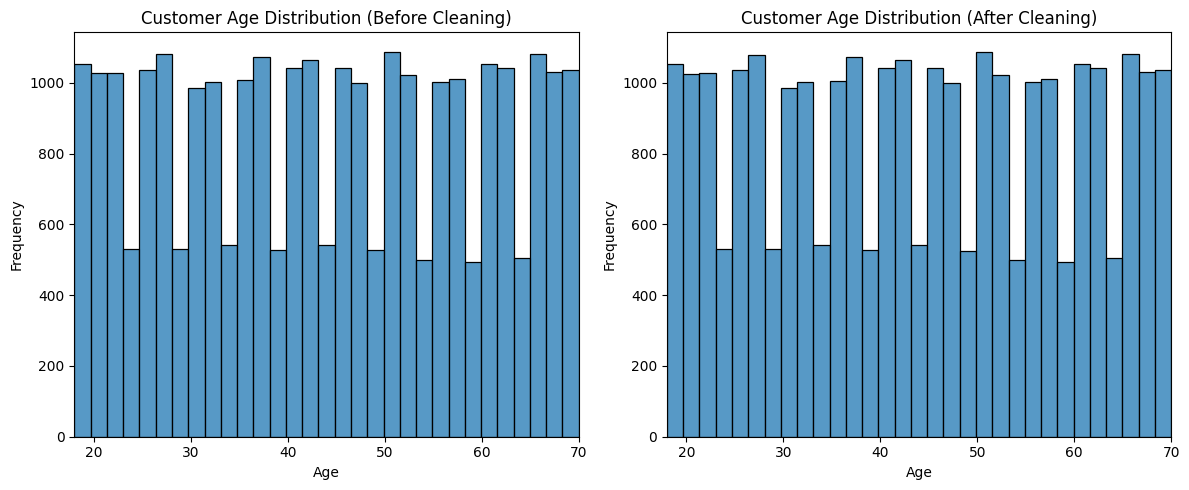

In [46]:
# Age Histogram - Before Cleaning
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(data=Historical_train_before, x="Age")
plt.title("Customer Age Distribution (Before Cleaning)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xlim(18, 70)

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(data=Historical_train, x="Age")
plt.title("Customer Age Distribution (After Cleaning)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xlim(18, 70)

plt.tight_layout()
plt.show()

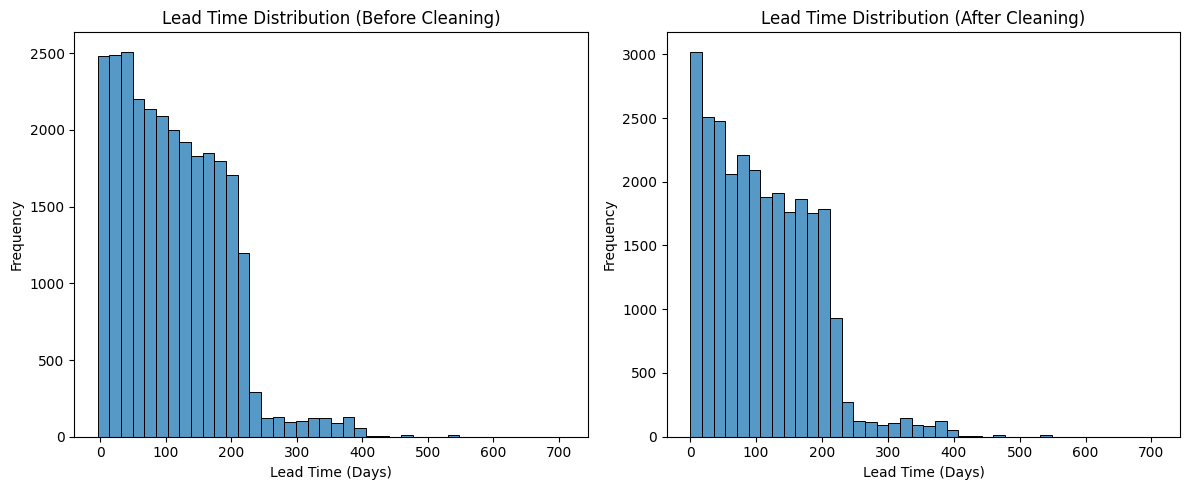

In [47]:
# Ensure date columns are datetime objects in the original DataFrame for Lead_Days calculation
Historical_train_before['Expected_checkin'] = pd.to_datetime(Historical_train_before['Expected_checkin'])
Historical_train_before['Booking_date'] = pd.to_datetime(Historical_train_before['Booking_date'])
Historical_train_before['Lead_Days'] = (Historical_train_before['Expected_checkin'] - Historical_train_before['Booking_date']).dt.days

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(data=Historical_train_before, x="Lead_Days", bins=40)
plt.title("Lead Time Distribution (Before Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(data=Historical_train, x="Lead_Days", bins=40)
plt.title("Lead Time Distribution (After Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

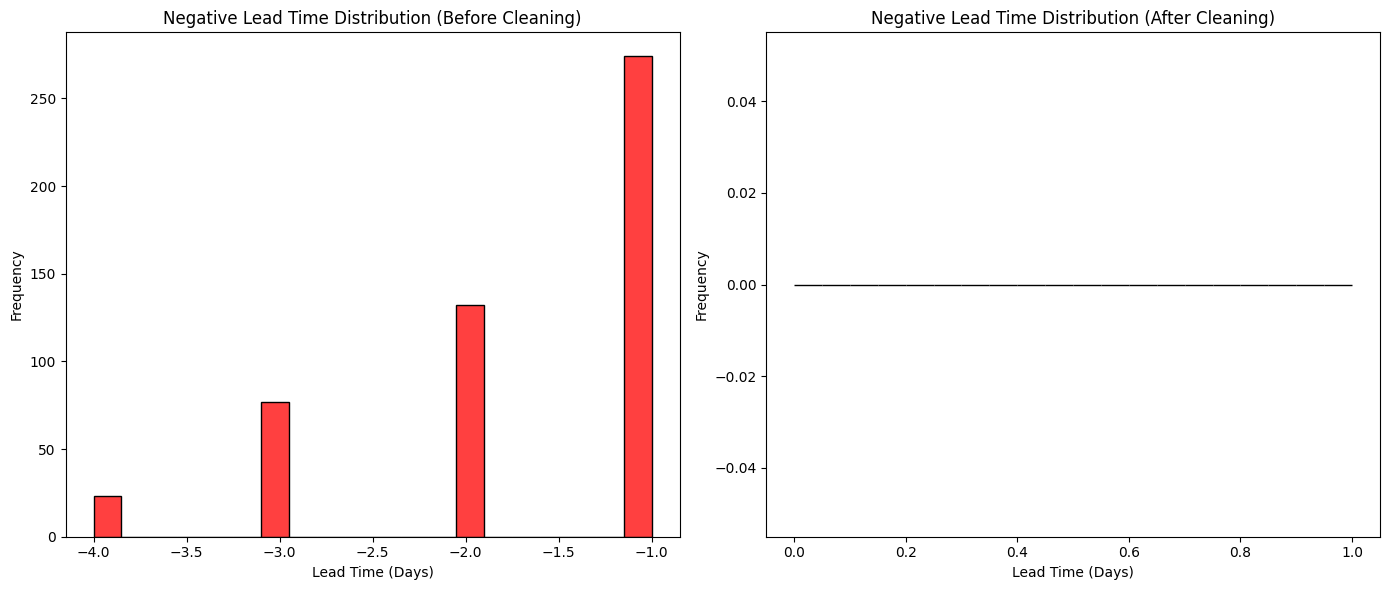

In [48]:

# Convert date columns to datetime for original dataset to calculate Lead_Days
Historical_train_before['Expected_checkin'] = pd.to_datetime(Historical_train_before['Expected_checkin'])
Historical_train_before['Booking_date'] = pd.to_datetime(Historical_train_before['Booking_date'])
Historical_train_before['Lead_Days'] = (Historical_train_before['Expected_checkin'] - Historical_train_before['Booking_date']).dt.days

# Filter for negative Lead_Days in the original dataset
negative_lead_days_original = Historical_train_before[Historical_train_before['Lead_Days'] < 0]

# Filter for negative Lead_Days in the cleaned dataset (should be empty after imputation to 0)
negative_lead_days_cleaned = Historical_train[Historical_train['Lead_Days'] < 0]

plt.figure(figsize=(14, 6))

# Plot for Original Data (before imputation)
plt.subplot(1, 2, 1)
sns.histplot(data=negative_lead_days_original, x="Lead_Days", bins=20, color='red')
plt.title("Negative Lead Time Distribution (Before Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

# Plot for Cleaned Data (after imputation)
plt.subplot(1, 2, 2)
sns.histplot(data=negative_lead_days_cleaned, x="Lead_Days", bins=20, color='red')
plt.title("Negative Lead Time Distribution (After Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

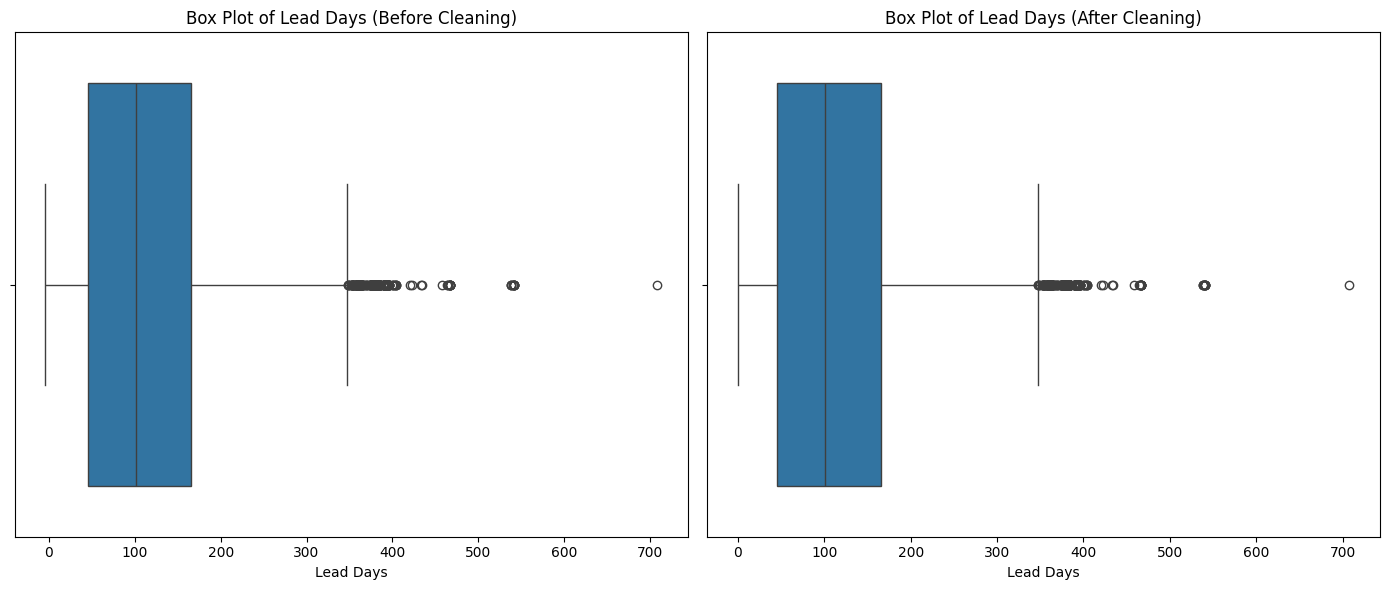

In [49]:
plt.figure(figsize=(14, 6))

# Box plot for original data (before cleaning)
plt.subplot(1, 2, 1)
sns.boxplot(x=Historical_train_before['Lead_Days'])
plt.title('Box Plot of Lead Days (Before Cleaning)')
plt.xlabel('Lead Days')

# Box plot for cleaned data (after cleaning)
plt.subplot(1, 2, 2)
sns.boxplot(x=Historical_train['Lead_Days'])
plt.title('Box Plot of Lead Days (After Cleaning)')
plt.xlabel('Lead Days')

plt.tight_layout()
plt.show()

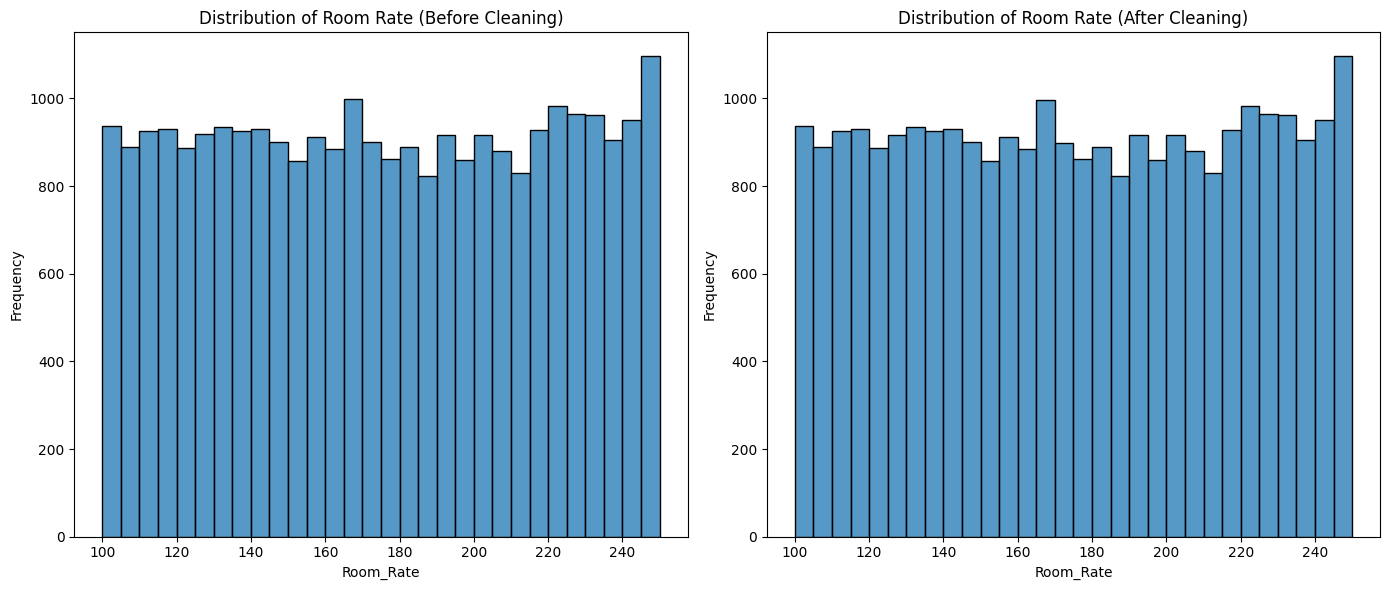

In [50]:

plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.histplot(data=Historical_train_before, x="Room_Rate", bins=30)
plt.title("Distribution of Room Rate (Before Cleaning)")
plt.xlabel("Room_Rate")
plt.ylabel("Frequency")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.histplot(data=Historical_train, x="Room_Rate", bins=30)
plt.title("Distribution of Room Rate (After Cleaning)")
plt.xlabel("Room_Rate")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

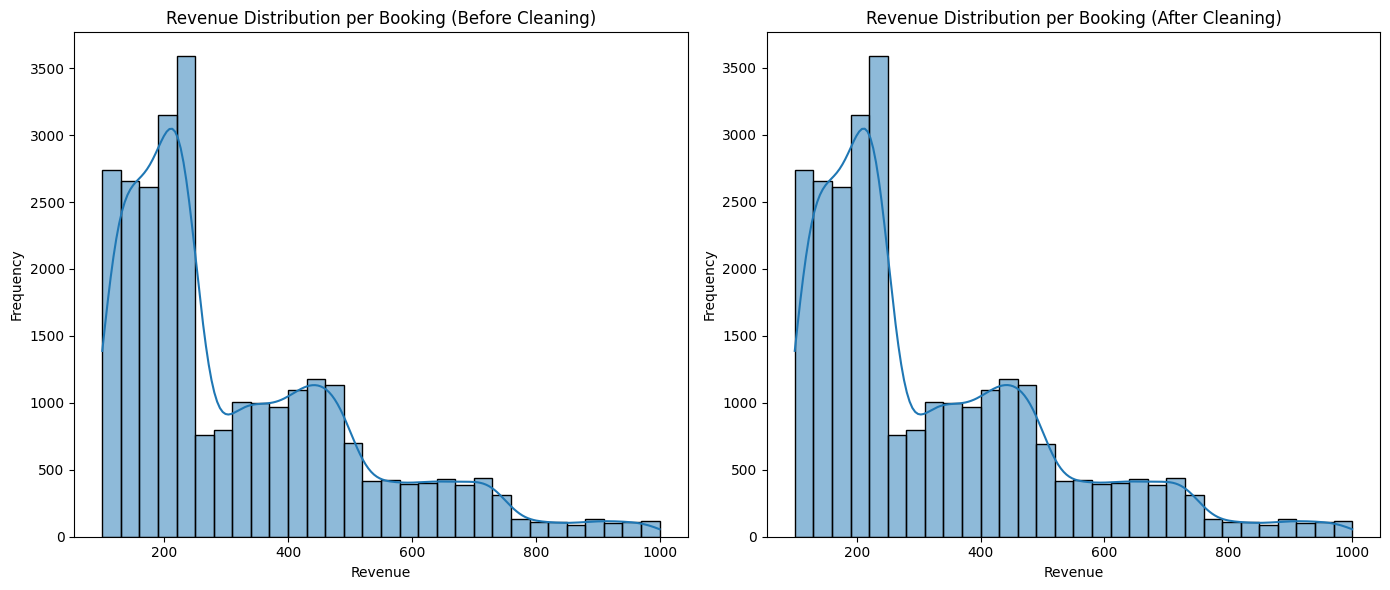

In [51]:
# Calculate stay_nights for Historical_train_before
Historical_train_before['stay_nights'] = (Historical_train_before['Expected_checkout'] - Historical_train_before['Expected_checkin']).dt.days

# Calculate Revenue for Historical_train_before
Historical_train_before['Revenue'] = Historical_train_before['stay_nights'] * Historical_train_before['Room_Rate']

plt.figure(figsize=(14, 6))

# Plot for Original Data (Before Cleaning)
plt.subplot(1, 2, 1)
sns.histplot(Historical_train_before['Revenue'], bins=30, kde=True)
plt.title("Revenue Distribution per Booking (Before Cleaning)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

# Plot for Cleaned Data (After Cleaning)
plt.subplot(1, 2, 2)
sns.histplot(Historical_train['Revenue'], bins=30, kde=True)
plt.title("Revenue Distribution per Booking (After Cleaning)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

/tmp/ipykernel_12567/162884173.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Historical_train_before, x="Room_Rate", palette="viridis")
/tmp/ipykernel_12567/162884173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Historical_train, x="Room_Rate", palette="viridis")
/tmp/ipykernel_12567/162884173.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Historical_train_before, x="Discount_Rate", palette="plasma")
/tmp/ipykernel_12567/162884173.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

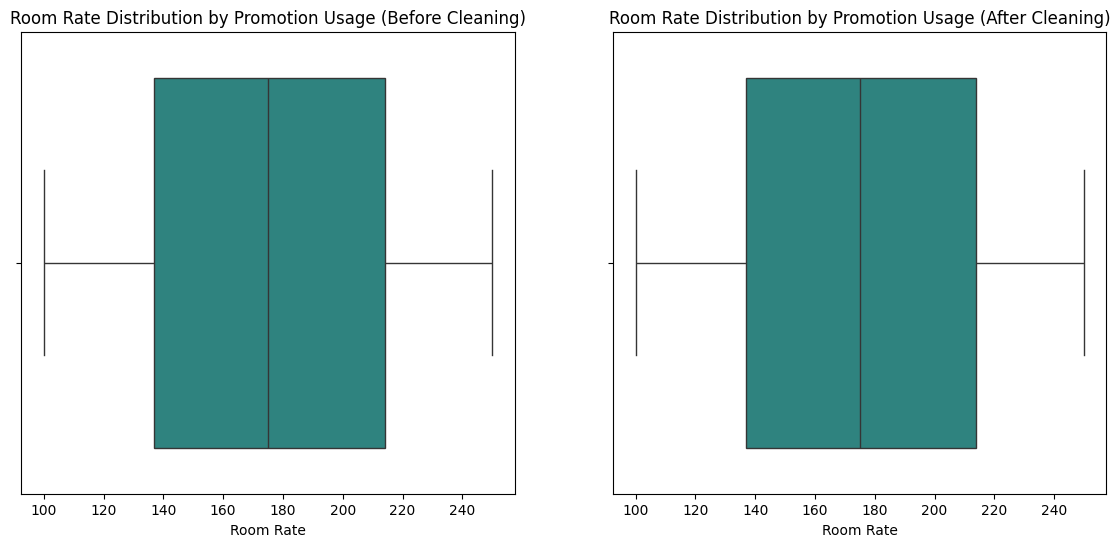

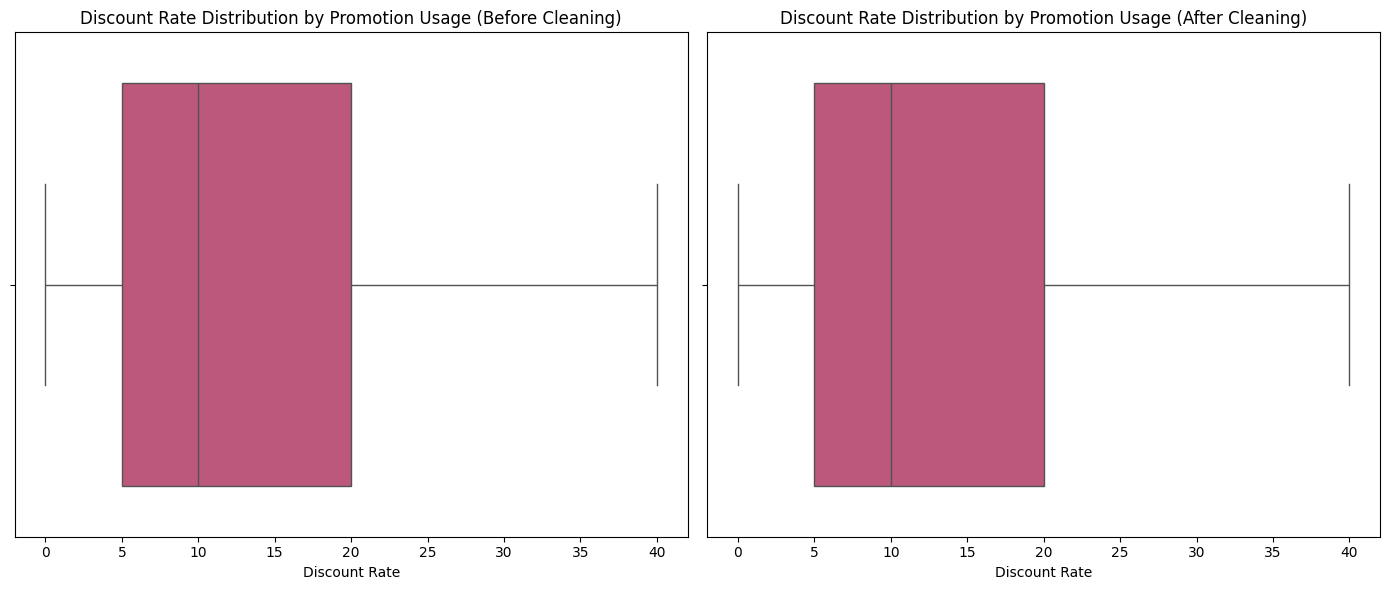

In [52]:

plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=Historical_train_before, x="Room_Rate", palette="viridis")
plt.title("Room Rate Distribution by Promotion Usage (Before Cleaning)")
plt.xlabel("Room Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=Historical_train, x="Room_Rate", palette="viridis")
plt.title("Room Rate Distribution by Promotion Usage (After Cleaning)")
plt.xlabel("Room Rate")

plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=Historical_train_before, x="Discount_Rate", palette="plasma")
plt.title("Discount Rate Distribution by Promotion Usage (Before Cleaning)")
plt.xlabel("Discount Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=Historical_train, x="Discount_Rate", palette="plasma")
plt.title("Discount Rate Distribution by Promotion Usage (After Cleaning)")
plt.xlabel("Discount Rate")

plt.tight_layout()
plt.show()


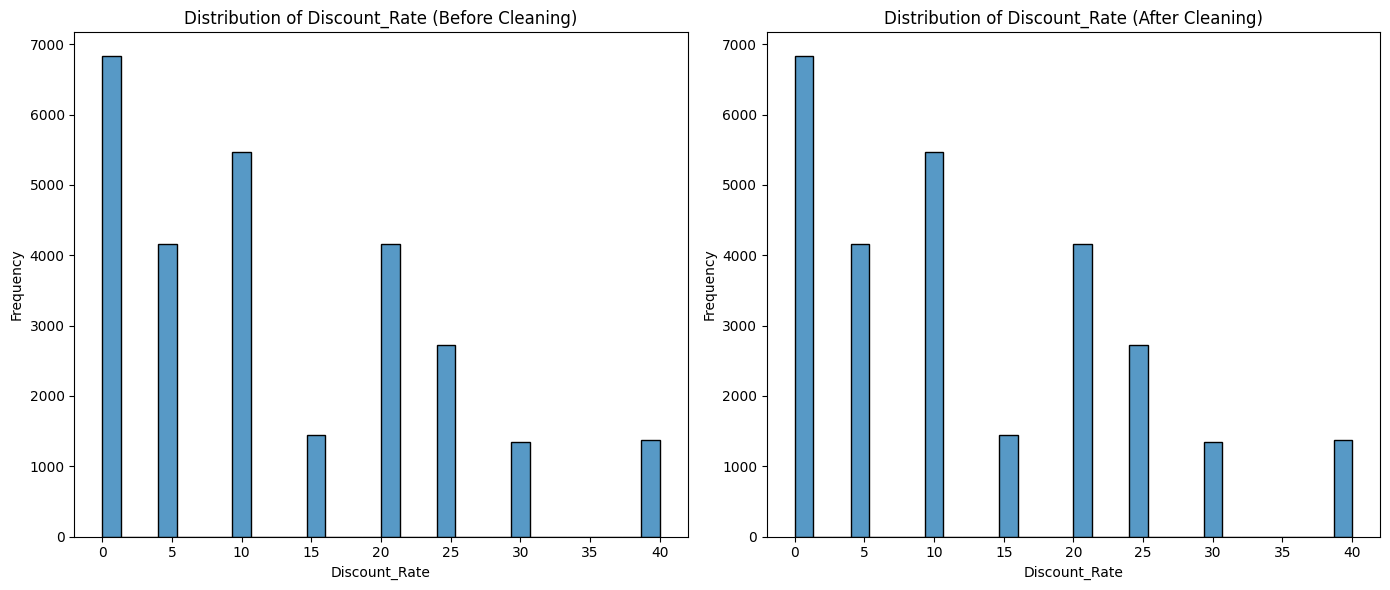

In [53]:
plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.histplot(data=Historical_train_before, x="Discount_Rate", bins=30)
plt.title("Distribution of Discount_Rate (Before Cleaning)")
plt.xlabel("Discount_Rate")
plt.ylabel("Frequency")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.histplot(data=Historical_train, x="Discount_Rate", bins=30)
plt.title("Distribution of Discount_Rate (After Cleaning)")
plt.xlabel("Discount_Rate")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

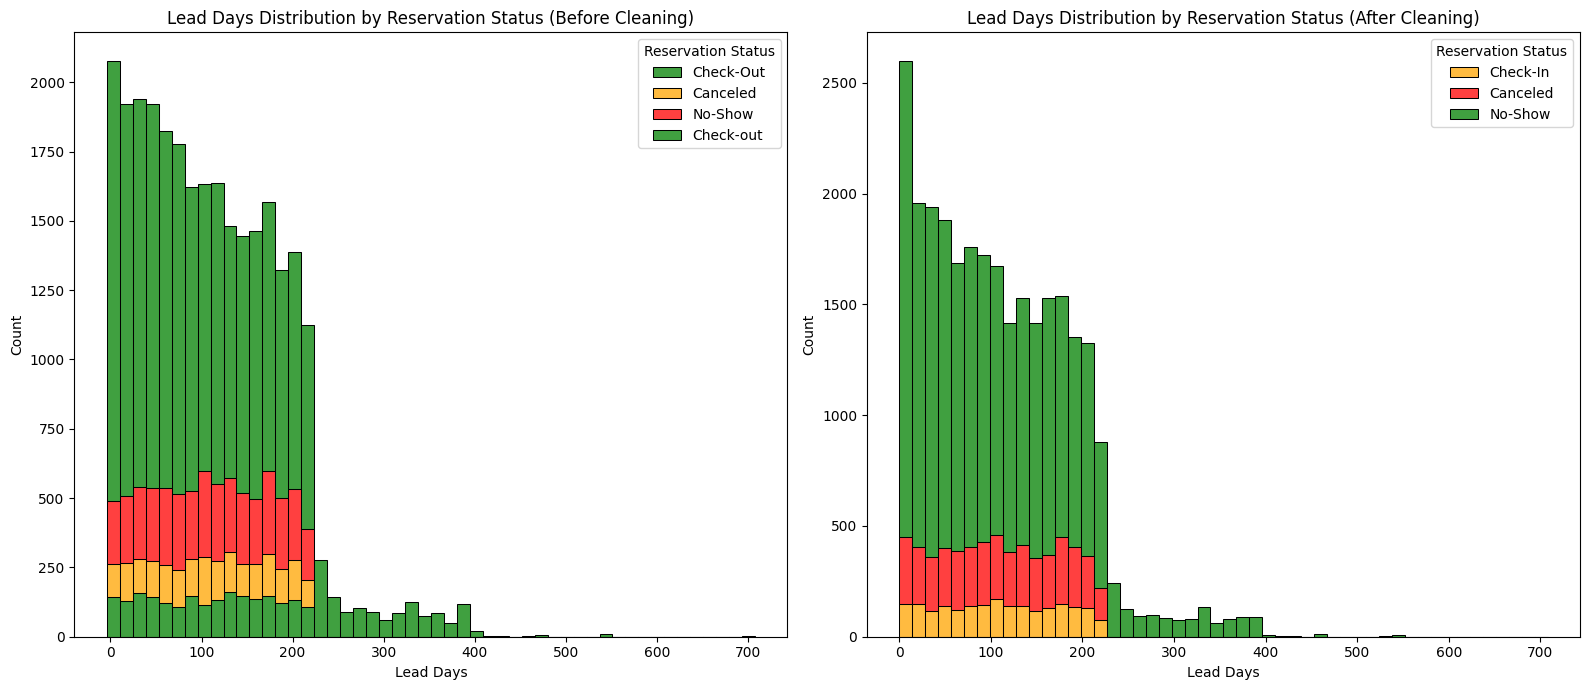

In [173]:
# Define a custom color map for consistent visualization
status_color_map = {
    1: 'green',        # Check-In/Check-Out (cleaned)
    2: 'red',          # Canceled (cleaned)
    3: 'orange',       # No-Show (cleaned)
    'Check-Out': 'green',
    'Check-out': 'green',
    'Canceled': 'red',
    'No-Show': 'orange'
}

plt.figure(figsize=(16, 7))

# Plot for Original Data (Before Cleaning)
plt.subplot(1, 2, 1)
sns.histplot(data=Historical_train_before, x='Lead_Days', hue='Reservation_Status', multiple='stack', palette=status_color_map, bins=50)
plt.title('Lead Days Distribution by Reservation Status (Before Cleaning)')
plt.xlabel('Lead Days')
plt.ylabel('Count')
plt.legend(title='Reservation Status', labels=Historical_train_before['Reservation_Status'].unique())

# Plot for Cleaned Data (After Cleaning)
plt.subplot(1, 2, 2)
sns.histplot(data=Historical_train, x='Lead_Days', hue='Reservation_Status', multiple='stack', palette=status_color_map, bins=50)
plt.title('Lead Days Distribution by Reservation Status (After Cleaning)')
plt.xlabel('Lead Days')
plt.ylabel('Count')
plt.legend(title='Reservation Status', labels=['Check-In', 'Canceled', 'No-Show'])

plt.tight_layout()
plt.show()

#Lead time is a strong behavioral indicator, as early bookings increase uncertainty and cancellation likelihood, whereas last-minute bookings reflect higher commitment and lower risk.

### **Bivariate Analysis**

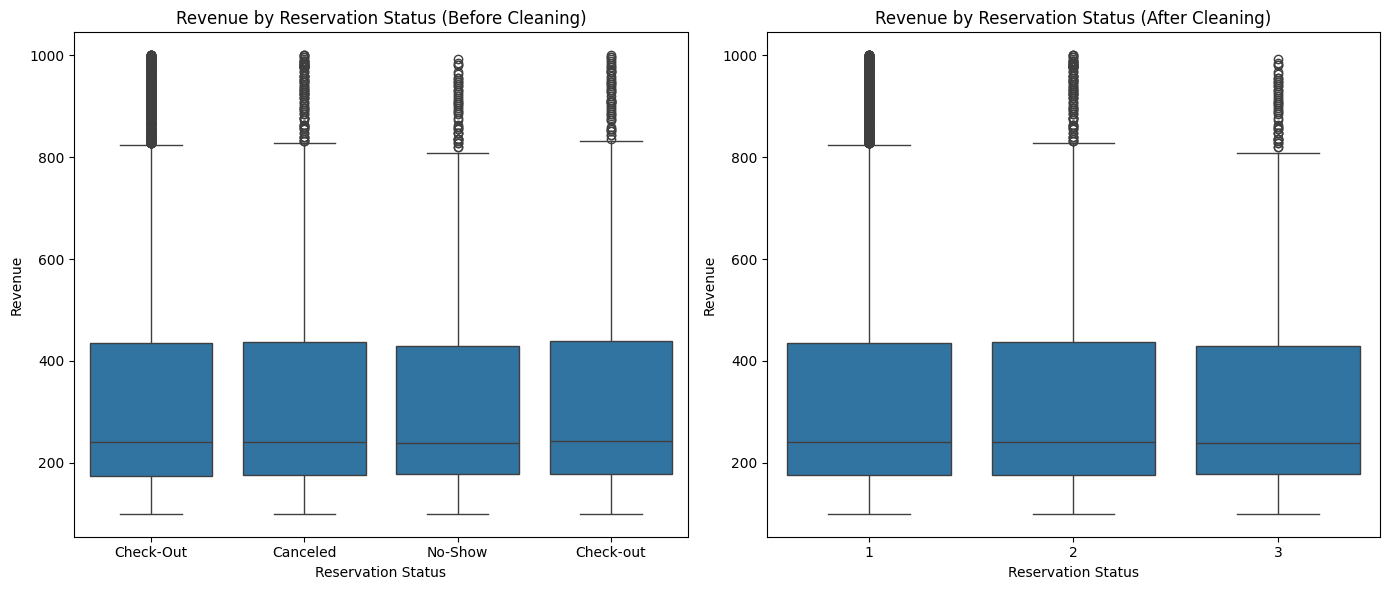

In [54]:
plt.figure(figsize=(14, 6))

# Plot for Original Data (Before Cleaning)
plt.subplot(1, 2, 1)
sns.boxplot(x='Reservation_Status', y='Revenue', data=Historical_train_before)
plt.title("Revenue by Reservation Status (Before Cleaning)")
plt.xlabel("Reservation Status")
plt.ylabel("Revenue")

# Plot for Cleaned Data (After Cleaning)
plt.subplot(1, 2, 2)
sns.boxplot(x='Reservation_Status', y='Revenue', data=Historical_train)
plt.title("Revenue by Reservation Status (After Cleaning)")
plt.xlabel("Reservation Status")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

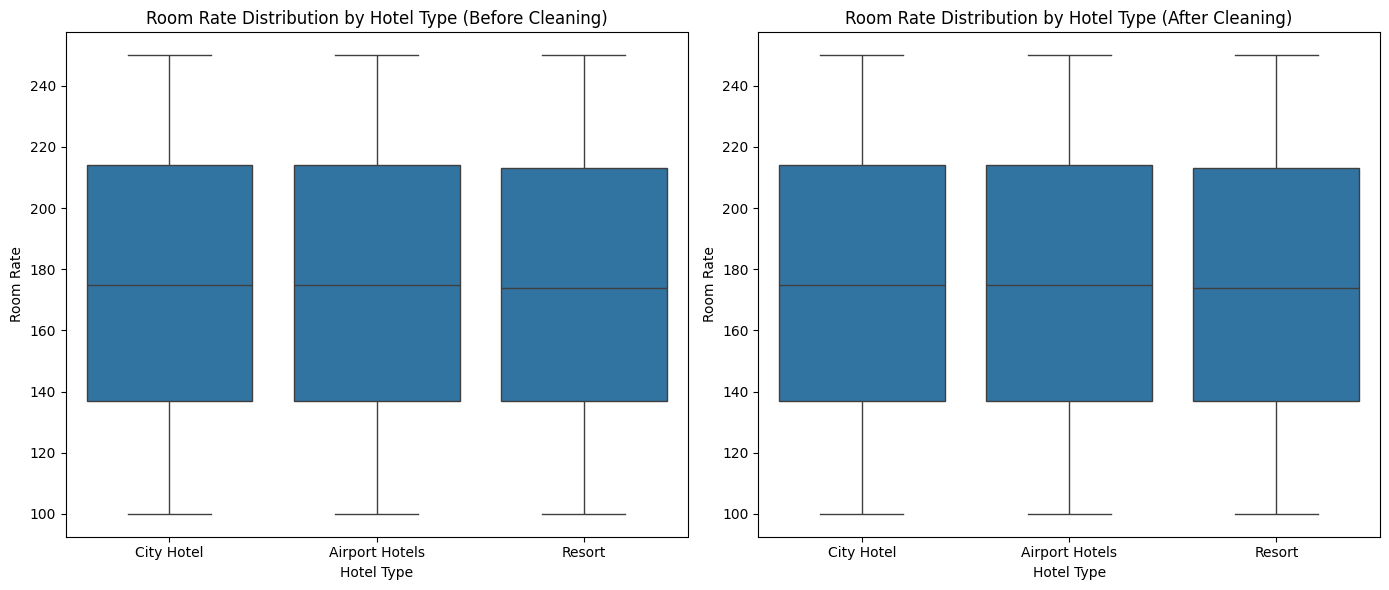

In [55]:

plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=Historical_train_before, x="Hotel_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Hotel Type (Before Cleaning)")
plt.xlabel("Hotel Type")
plt.ylabel("Room Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=Historical_train, x="Hotel_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Hotel Type (After Cleaning)")
plt.xlabel("Hotel Type")
plt.ylabel("Room Rate")

plt.tight_layout()
plt.show()

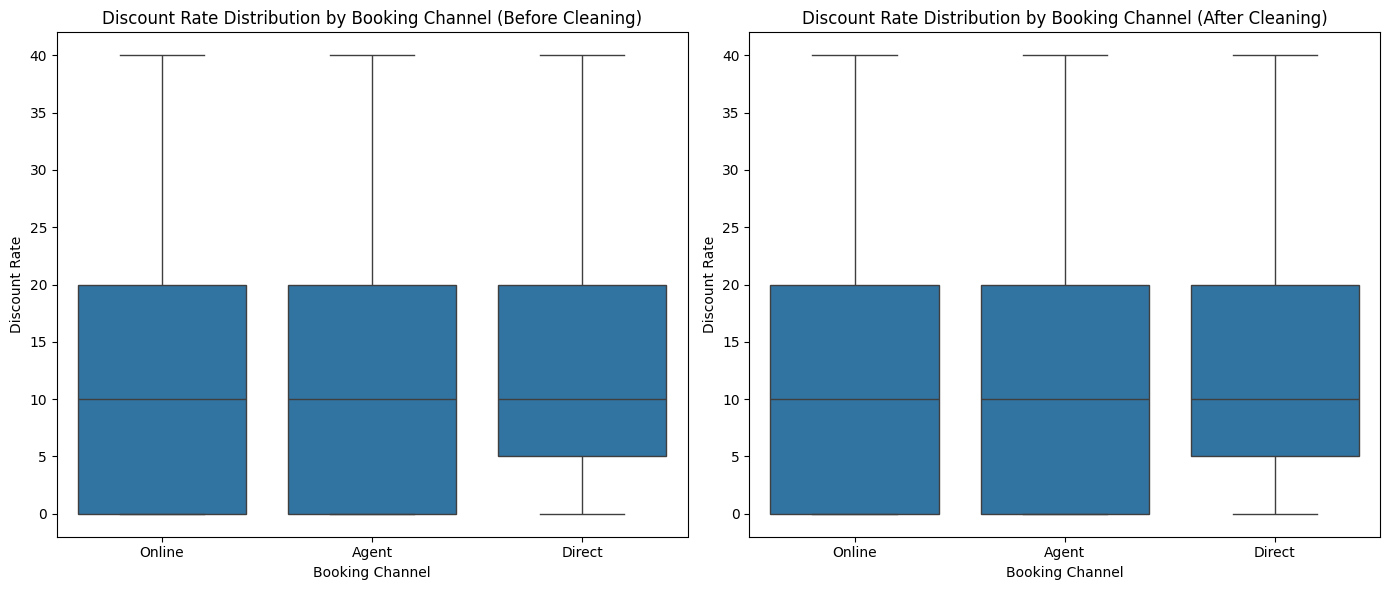

In [56]:

plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=Historical_train_before, x="Booking_channel", y="Discount_Rate")
plt.title("Discount Rate Distribution by Booking Channel (Before Cleaning)")
plt.xlabel("Booking Channel")
plt.ylabel("Discount Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=Historical_train, x="Booking_channel", y="Discount_Rate")
plt.title("Discount Rate Distribution by Booking Channel (After Cleaning)")
plt.xlabel("Booking Channel")
plt.ylabel("Discount Rate")

plt.tight_layout()
plt.show()

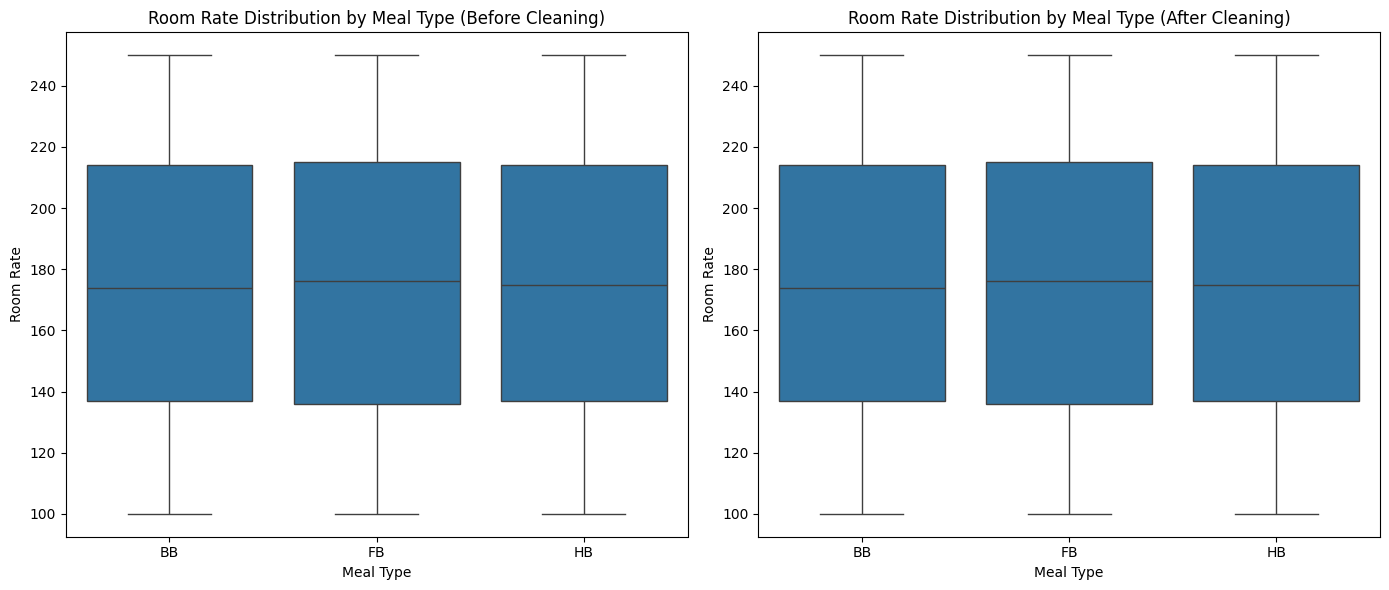

In [57]:

plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=Historical_train_before, x="Meal_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Meal Type (Before Cleaning)")
plt.xlabel("Meal Type")
plt.ylabel("Room Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=Historical_train, x="Meal_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Meal Type (After Cleaning)")
plt.xlabel("Meal Type")
plt.ylabel("Room Rate")

plt.tight_layout()
plt.show()

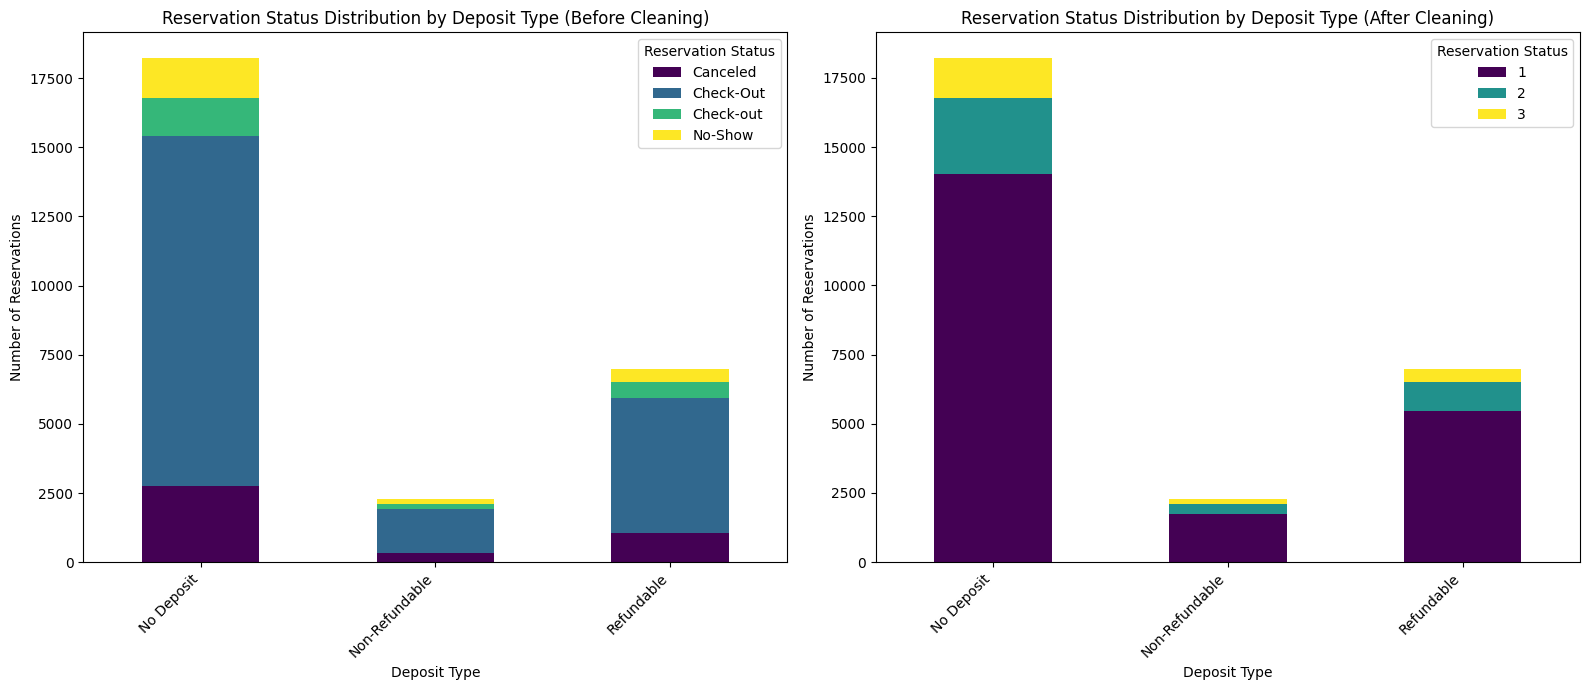

In [168]:
# Group by Deposit_type and Reservation_Status and count occurrences for original data
deposit_status_counts_original = Historical_train_before.groupby(['Deposit_type', 'Reservation_Status']).size().unstack(fill_value=0)

# Group by Deposit_type and Reservation_Status and count occurrences for cleaned data
deposit_status_counts_cleaned = Historical_train.groupby(['Deposit_type', 'Reservation_Status']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 7))

# Plot for Original Data
plt.subplot(1, 2, 1)
deposit_status_counts_original.plot(kind='bar', stacked=True, cmap='viridis', ax=plt.gca())
plt.title('Reservation Status Distribution by Deposit Type (Before Cleaning)')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Reservations')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reservation Status')

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
deposit_status_counts_cleaned.plot(kind='bar', stacked=True, cmap='viridis', ax=plt.gca())
plt.title('Reservation Status Distribution by Deposit Type (After Cleaning)')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Reservations')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reservation Status')

plt.tight_layout()
plt.show()

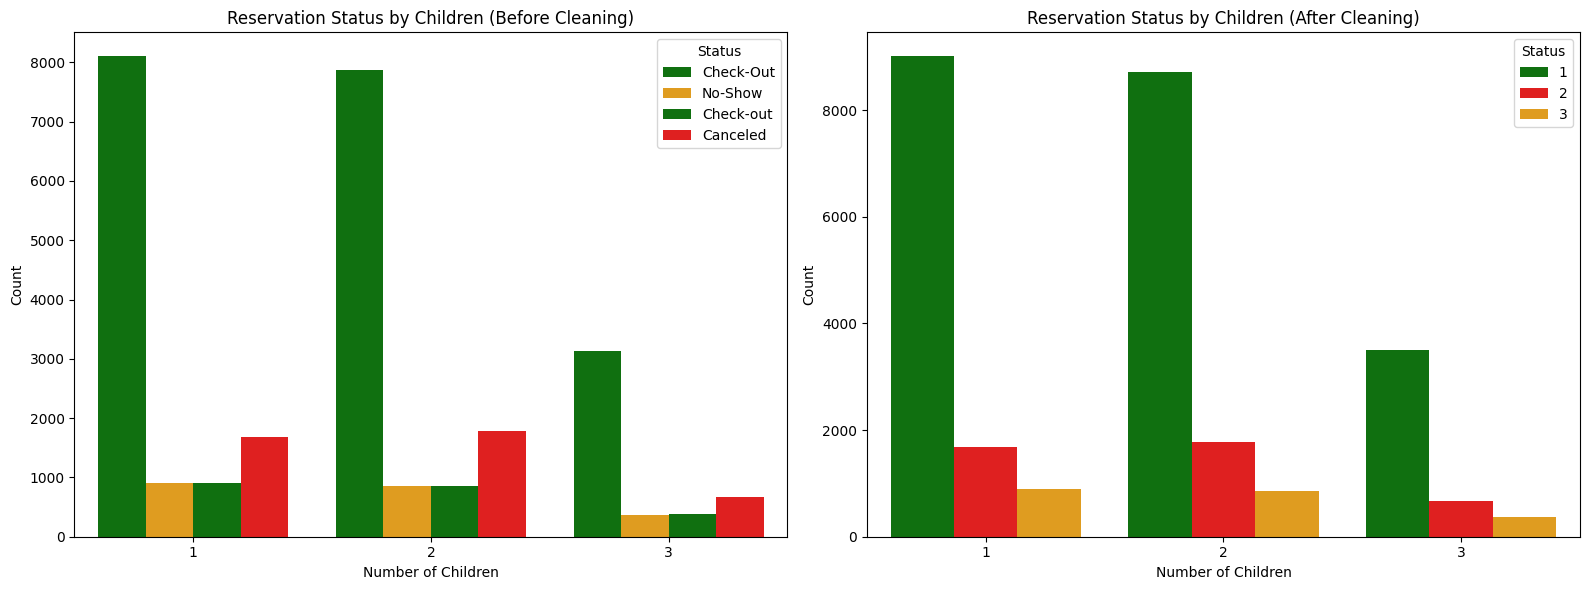

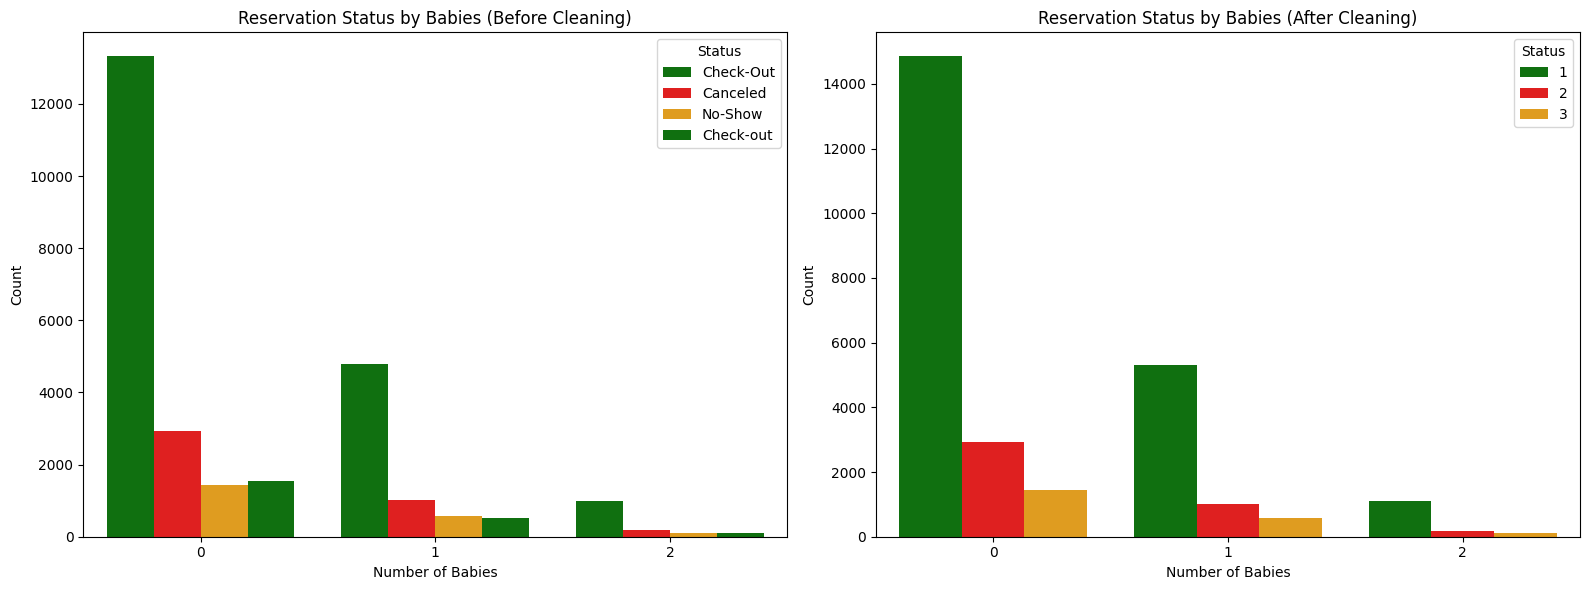

In [170]:
# Define a custom color map for consistent visualization
status_color_map = {
    1: 'green',        # Check-In/Check-Out (cleaned)
    2: 'red',          # Canceled (cleaned)
    3: 'orange',       # No-Show (cleaned)
    'Check-Out': 'green',
    'Check-out': 'green',
    'Canceled': 'red',
    'No-Show': 'orange'
}

# --- Comparison for 'Children' vs. 'Reservation_Status' ---
plt.figure(figsize=(16, 6))

# Before Cleaning (Children)
plt.subplot(1, 2, 1)
sns.countplot(data=Historical_train_before, x='Children', hue='Reservation_Status', palette=status_color_map)
plt.title('Reservation Status by Children (Before Cleaning)')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.legend(title='Status')

# After Cleaning (Children)
plt.subplot(1, 2, 2)
sns.countplot(data=Historical_train, x='Children', hue='Reservation_Status', palette=status_color_map)
plt.title('Reservation Status by Children (After Cleaning)')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.legend(title='Status')

plt.tight_layout()
plt.show()

# --- Comparison for 'Babies' vs. 'Reservation_Status' ---
plt.figure(figsize=(16, 6))

# Before Cleaning (Babies)
plt.subplot(1, 2, 1)
sns.countplot(data=Historical_train_before, x='Babies', hue='Reservation_Status', palette=status_color_map)
plt.title('Reservation Status by Babies (Before Cleaning)')
plt.xlabel('Number of Babies')
plt.ylabel('Count')
plt.legend(title='Status')

# After Cleaning (Babies)
plt.subplot(1, 2, 2)
sns.countplot(data=Historical_train, x='Babies', hue='Reservation_Status', palette=status_color_map)
plt.title('Reservation Status by Babies (After Cleaning)')
plt.xlabel('Number of Babies')
plt.ylabel('Count')
plt.legend(title='Status')

plt.tight_layout()
plt.show()

### **Multivariate Analysis**

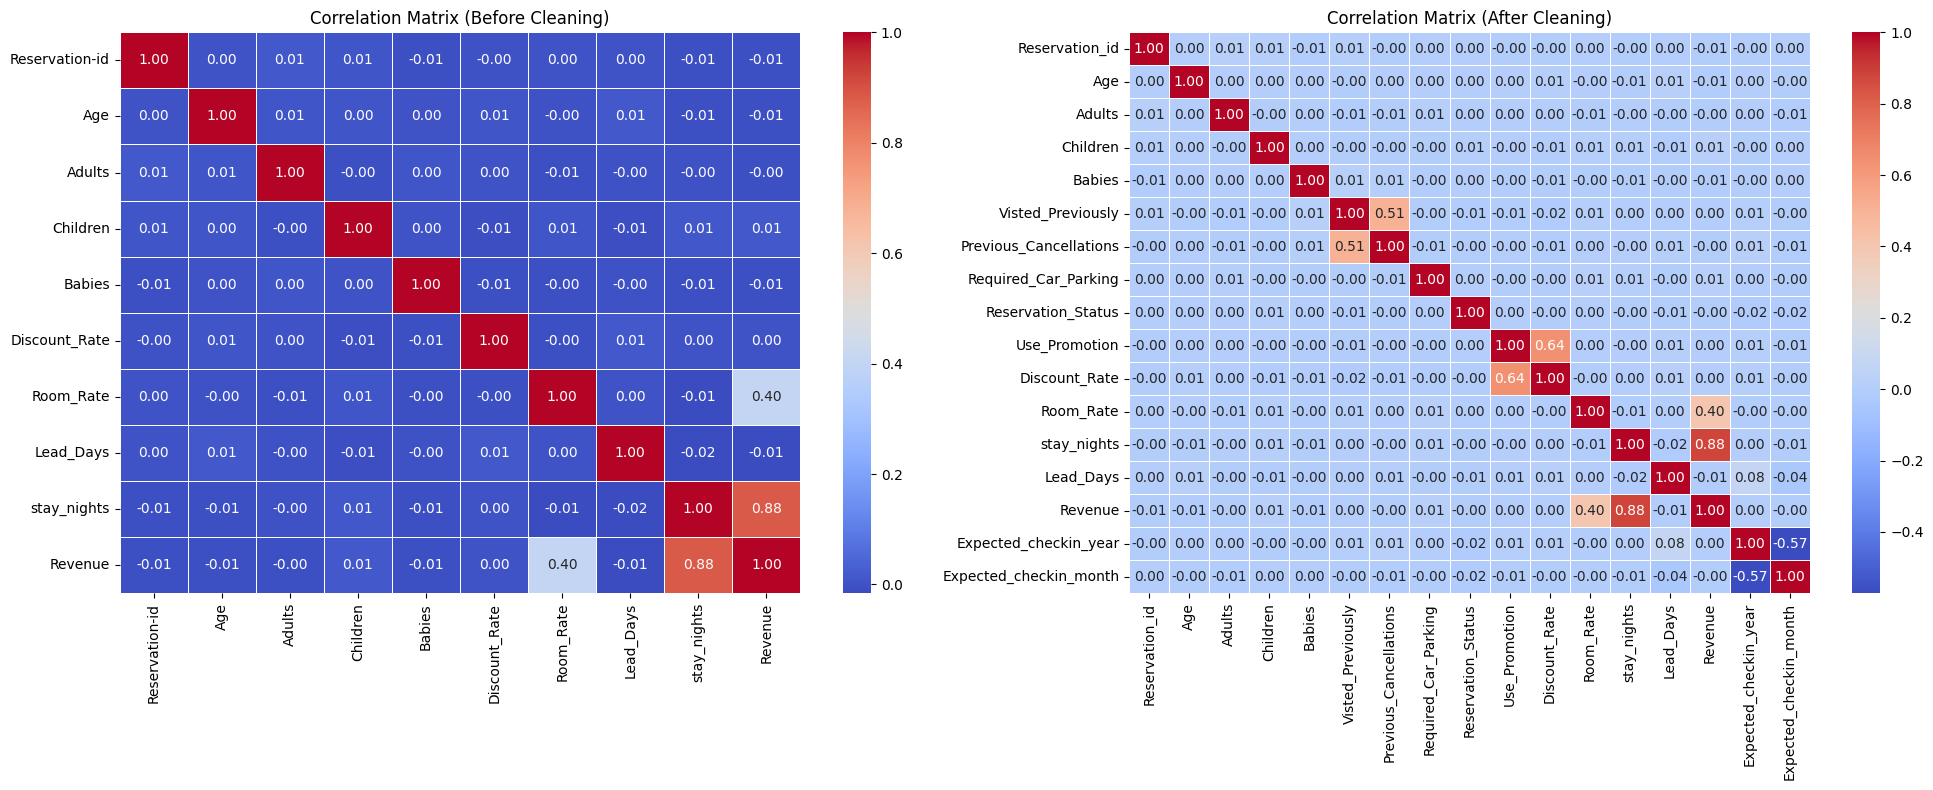

In [59]:

plt.figure(figsize=(20, 8))

# Plot for Original Data
plt.subplot(1, 2, 1)
correlation_matrix_original = Historical_train_before.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix_original, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix (Before Cleaning)')

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
correlation_matrix_cleaned = Historical_train.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix (After Cleaning)')

plt.tight_layout()
plt.show()

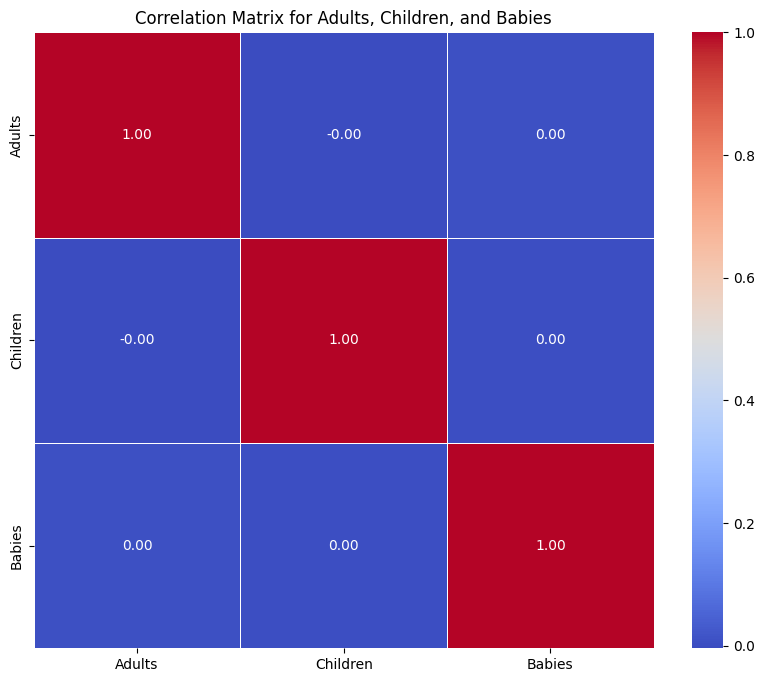

In [171]:
correlation_subset = Historical_train[['Adults', 'Children', 'Babies']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_subset, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix for Adults, Children, and Babies')
plt.show()

## **Exporting cleaned data**

In [60]:
Historical_train.to_csv('/content/drive/MyDrive/Hotel Revenue Prediction GCW/train_cleaned.csv', index=False)

# **Hotel 'A'- Test Dataset**

## **Data Exploration**

In [61]:
# Reading the CSV files
test =  pd.read_csv('/content/drive/MyDrive/Hotel Revenue Prediction GCW/Hotel-A-test.csv')

In [62]:
#Load dataset
test

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Babies,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Use_Promotion,Discount_Rate,Room_Rate
0,62931593,F,52,Latino,Grad,25K --50K,South,City Hotel,11/18/2016,11/19/2016,...,0,HB,No,No,No Deposit,Direct,Yes,Yes,10,153
1,70586099,F,47,Latino,Grad,25K --50K,East,Airport Hotels,11/18/2016,11/19/2016,...,0,FB,No,No,No Deposit,Online,No,No,0,210
2,4230648,F,28,Asian American,Grad,<25K,East,City Hotel,4/28/2017,5/1/2017,...,0,BB,No,No,No Deposit,Agent,No,Yes,5,117
3,25192322,F,65,caucasian,High-School,25K --50K,South,Airport Hotels,11/18/2016,11/20/2016,...,2,FB,No,No,No Deposit,Online,Yes,Yes,10,107
4,80931528,M,45,African American,College,25K --50K,South,City Hotel,11/18/2016,11/20/2016,...,0,BB,No,No,Refundable,Agent,No,No,0,119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4313,39110574,M,53,Latino,College,50K -- 100K,South,Resort,3/29/2017,3/30/2017,...,1,FB,Yes,No,Non-Refundable,Online,Yes,No,0,153
4314,5496554,F,63,caucasian,College,50K -- 100K,South,Resort,3/29/2017,4/1/2017,...,0,HB,No,No,Refundable,Agent,Yes,Yes,40,233
4315,59004046,F,59,caucasian,Grad,<25K,East,Airport Hotels,3/29/2017,3/30/2017,...,0,FB,No,No,No Deposit,Direct,Yes,No,0,242
4316,65838682,M,43,African American,College,25K --50K,West,Resort,3/29/2017,3/30/2017,...,1,BB,No,No,No Deposit,Online,Yes,No,0,208


In [63]:
#No. of rows and columns in dataset
print(test.shape)

(4318, 23)


In [64]:
#Data types of each column in  dataset
print(test.dtypes)


Reservation-id             int64
Gender                    object
Age                        int64
Ethnicity                 object
Educational_Level         object
Income                    object
Country_region            object
Hotel_Type                object
Expected_checkin          object
Expected_checkout         object
Booking_date              object
Adults                     int64
Children                   int64
Babies                     int64
Meal_Type                 object
Visted_Previously         object
Previous_Cancellations    object
Deposit_type              object
Booking_channel           object
Required_Car_Parking      object
Use_Promotion             object
Discount_Rate              int64
Room_Rate                  int64
dtype: object


In [65]:
# Convert 'Expected_checkin', 'Expected_checkout' and 'Booking_date' to datetime objects
test['Expected_checkin'] = pd.to_datetime(test['Expected_checkin'])
test['Expected_checkout'] = pd.to_datetime(test['Expected_checkout'])
test['Booking_date'] = pd.to_datetime(test['Booking_date'])

In [66]:
test.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,datetime64[ns]
Expected_checkout,datetime64[ns]


In [67]:
#identify the missing data
print(test.isnull().sum())

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64


In [68]:
#Descriptive statistics for numeric attributes
test.describe().T

,count,mean,min,25%,50%,75%,max,std
Reservation-id,4318.0,50429081.111857,68318.0,25476853.0,51123488.0,75158645.0,99983667.0,28794252.427957
Age,4318.0,43.788328,18.0,31.0,44.0,57.0,70.0,15.257078
Expected_checkin,4318,2017-01-25 10:04:36.794812160,2016-03-02 00:00:00,2016-12-26 00:00:00,2017-01-29 00:00:00,2017-02-27 00:00:00,2017-09-01 00:00:00,NaN
Expected_checkout,4318,2017-01-27 05:47:09.643353600,2016-03-03 00:00:00,2016-12-28 00:00:00,2017-01-30 00:00:00,2017-03-01 00:00:00,2017-09-04 00:00:00,NaN
Booking_date,4318,2016-10-07 15:01:05.030106368,2015-07-30 00:00:00,2016-08-11 00:00:00,2016-10-06 00:00:00,2016-12-05 00:00:00,2017-06-24 00:00:00,NaN
Adults,4318.0,2.369847,1.0,2.0,2.0,3.0,5.0,1.191075
Children,4318.0,1.730199,1.0,1.0,2.0,2.0,3.0,0.721406
Babies,4318.0,0.345762,0.0,0.0,0.0,1.0,2.0,0.566368
Discount_Rate,4318.0,12.416628,0.0,5.0,10.0,20.0,40.0,11.266842
Room_Rate,4318.0,175.572024,100.0,139.0,176.0,212.0,250.0,42.941781


In [69]:
#Descriptive statistics for non-numeric attributes
test.describe(include='object').T

,count,unique,top,freq
Gender,4318,2,F,2169
Ethnicity,4318,4,Asian American,1114
Educational_Level,4318,4,College,1705
Income,4318,4,25K --50K,1244
Country_region,4318,4,South,1722
Hotel_Type,4318,3,Airport Hotels,1466
Meal_Type,4318,3,FB,1461
Visted_Previously,4318,2,No,2867
Previous_Cancellations,4318,2,No,3872
Deposit_type,4318,3,No Deposit,2872


In [70]:
from os import dup
# whole‑row duplicates
dup_row = test.duplicated(keep=False)
duplicates = test[dup_row]
print("Total duplicate rows:", dup_row.sum())


Total duplicate rows: 0


In [71]:
# Duplicates on a particular key
dup_id = test['Reservation-id'].duplicated(keep=False)
print("Rows sharing the same Reservation ID:", dup_id.sum())
dup_by_id = test[dup_id]


Rows sharing the same Reservation ID: 0


In [72]:
#Identifying unique values
unique_values_test = test.apply(pd.Series.unique)
print(unique_values_test)

Reservation-id            [62931593, 70586099, 4230648, 25192322, 809315...
Gender                                                               [F, M]
Age                       [52, 47, 28, 65, 45, 26, 27, 40, 44, 48, 49, 5...
Ethnicity                 [Latino, Asian American, caucasian, African Am...
Educational_Level                  [Grad, High-School, College, Mid-School]
Income                                [25K --50K, <25K, >100K, 50K -- 100K]
Country_region                                   [South, East, West, North]
Hotel_Type                             [City Hotel, Airport Hotels, Resort]
Expected_checkin          [2016-11-18 00:00:00, 2017-04-28 00:00:00, 201...
Expected_checkout         [2016-11-19 00:00:00, 2017-05-01 00:00:00, 201...
Booking_date              [2016-10-28 00:00:00, 2016-08-06 00:00:00, 201...
Adults                                                      [3, 2, 1, 4, 5]
Children                                                          [3, 1, 2]
Babies      

## **Before Cleaning - Exploratory Data Analysis**

### **Univariate Analysis**

In [73]:
test_before = test.copy()

In [74]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

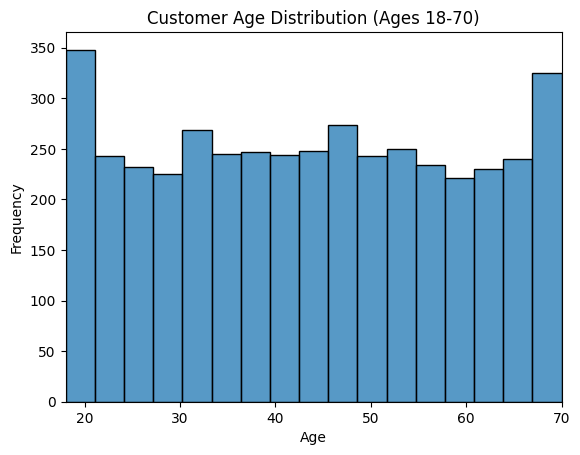

In [75]:
# Age Histogram
plt.figure()
sns.histplot(data=test_before, x="Age")
plt.title("Customer Age Distribution (Ages 18-70)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xlim(18, 70) # Set x-axis limits to 18-70
plt.show()

In [76]:
# Convert 'Expected_checkin' and 'Booking_date' to datetime objects
test_before['Expected_checkin'] = pd.to_datetime(test_before['Expected_checkin'])
test_before['Booking_date'] = pd.to_datetime(test_before['Booking_date'])

In [77]:
# Calculate Lead_Days
test_before['Lead_Days'] = (test_before['Expected_checkin'] - test_before['Booking_date']).dt.days

# Display the first few rows with the new 'Lead_Days' column
display(test_before[['Expected_checkin', 'Booking_date', 'Lead_Days']].head())

,Expected_checkin,Booking_date,Lead_Days
0,2016-11-18,2016-10-28,21
1,2016-11-18,2016-08-06,104
2,2017-04-28,2017-04-08,20
3,2016-11-18,2016-05-20,182
4,2016-11-18,2016-10-31,18


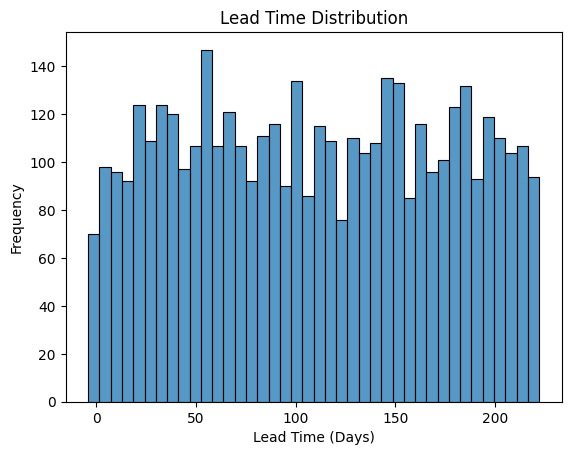

In [78]:
# Lead Time Histogram
plt.figure()
sns.histplot(data=test_before, x="Lead_Days", bins=40)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

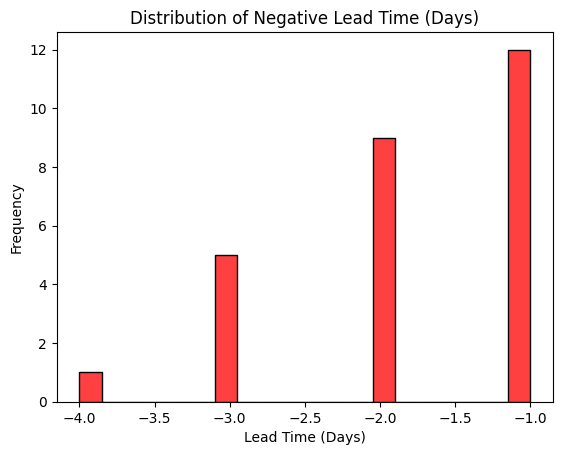

In [79]:
# Filter for negative Lead_Days
negative_lead_days_test = test_before[test_before['Lead_Days'] < 0]

# Histogram for negative Lead_Days
plt.figure()
sns.histplot(data=negative_lead_days_test, x="Lead_Days", bins=20, color='red')
plt.title("Distribution of Negative Lead Time (Days)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

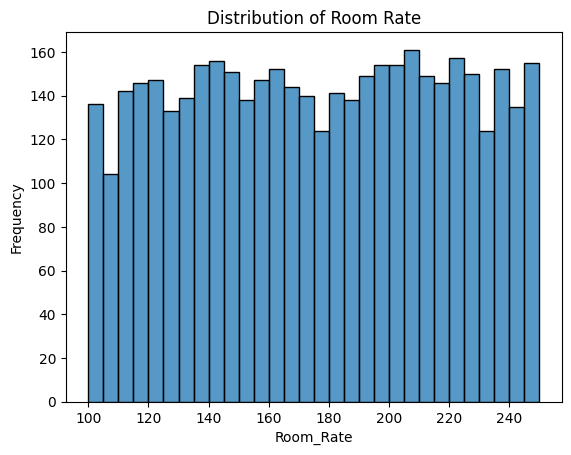

In [80]:
# Distribution of Room Rate
plt.figure()
sns.histplot(data=test_before, x="Room_Rate", bins=30)
plt.title("Distribution of Room Rate")
plt.xlabel("Room_Rate")
plt.ylabel("Frequency")
plt.show()

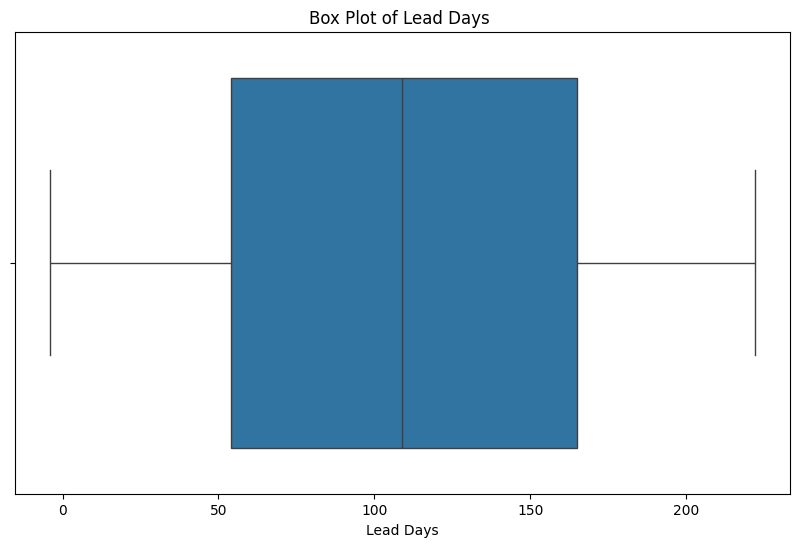

In [81]:
# Box plot to identify outliers in Lead_Days
plt.figure(figsize=(10, 6))
sns.boxplot(x=test_before['Lead_Days'])
plt.title('Box Plot of Lead Days ')
plt.xlabel('Lead Days')
plt.show()

/tmp/ipykernel_12567/2128425572.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_before, x="Discount_Rate", palette="plasma")


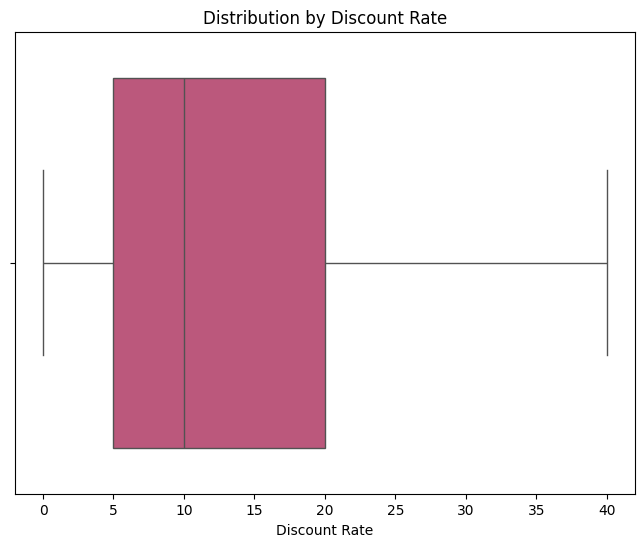

In [82]:
# Box plot for Discount_Rate by Use_Promotion
plt.figure(figsize=(8, 6))
sns.boxplot(data=test_before, x="Discount_Rate", palette="plasma")
plt.title("Distribution by Discount Rate")
plt.xlabel("Discount Rate")
plt.show()

/tmp/ipykernel_12567/3543792055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_before, x="Room_Rate", palette="viridis")


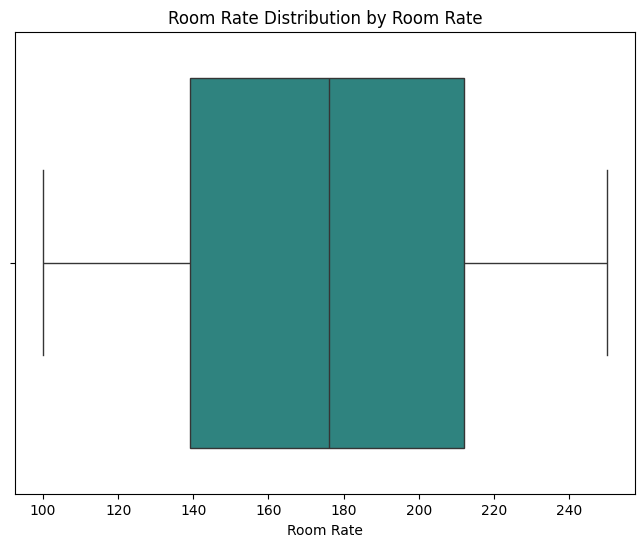

In [83]:
# Box plot for Room_Rate by Use_Promotion
plt.figure(figsize=(8, 6))
sns.boxplot(data=test_before, x="Room_Rate", palette="viridis")
plt.title("Room Rate Distribution by Room Rate")
plt.xlabel("Room Rate")
plt.show()

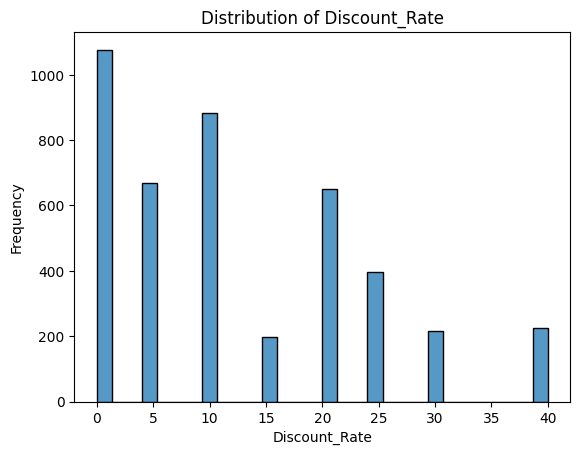

In [84]:
# Distribution of Discount_Rate
plt.figure()
sns.histplot(data=test_before, x="Discount_Rate", bins=30)
plt.title("Distribution of Discount_Rate")
plt.xlabel("Discount_Rate")
plt.ylabel("Frequency")
plt.show()

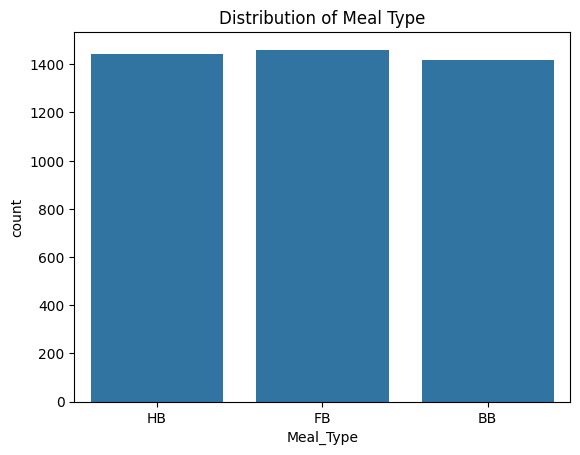

In [85]:
sns.countplot(data=test_before, x="Meal_Type")
plt.title("Distribution of Meal Type")
plt.show()

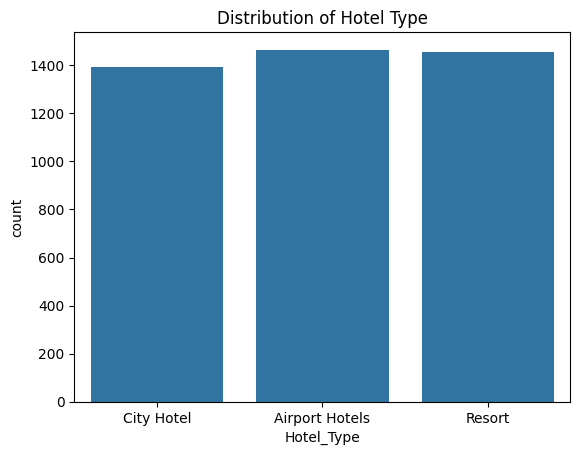

In [86]:
sns.countplot(data=test_before, x="Hotel_Type")
plt.title("Distribution of Hotel Type")
plt.show()

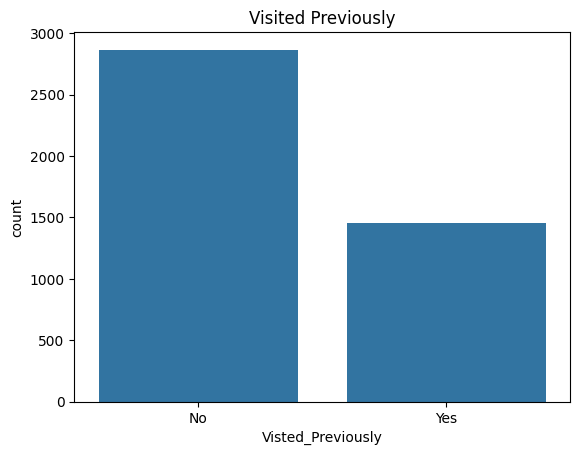

In [87]:
sns.countplot(data=test_before, x="Visted_Previously")
plt.title("Visited Previously")
plt.show()

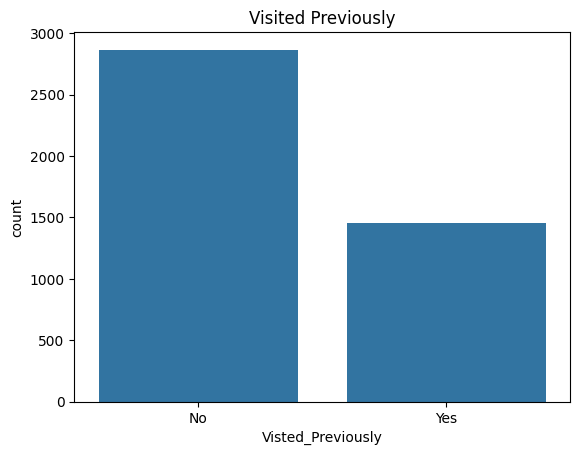

In [88]:
sns.countplot(data=test_before, x="Visted_Previously")
plt.title("Visited Previously")
plt.show()

Text(0.5, 1.0, 'Customer Region Distribution')

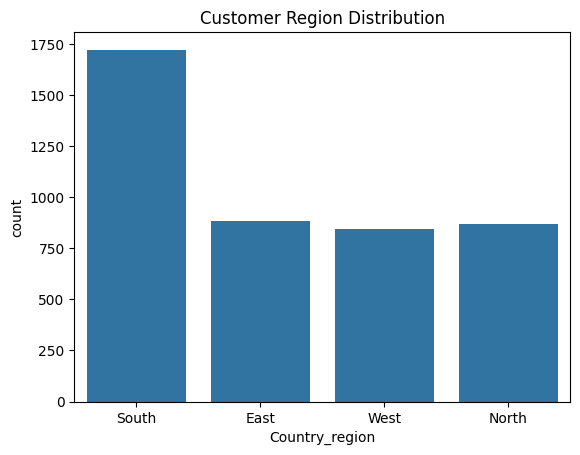

In [89]:
sns.countplot(data=test_before, x="Country_region")
plt.title("Customer Region Distribution")

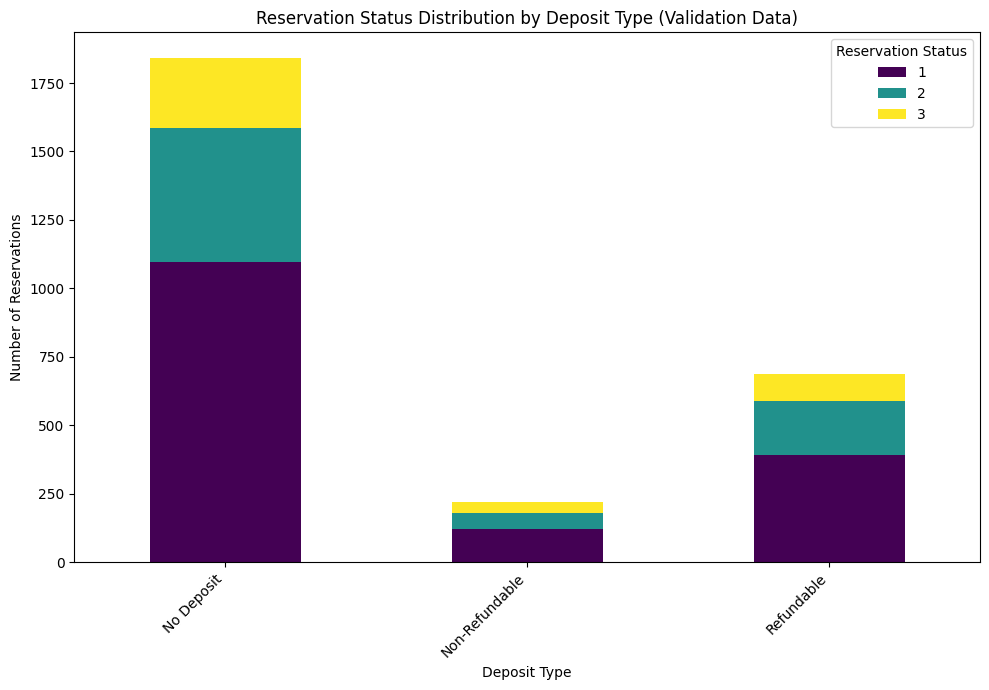

In [164]:
deposit_status_counts_valid = valid.groupby(['Deposit_type', 'Reservation_Status']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 7))
deposit_status_counts_valid.plot(kind='bar', stacked=True, cmap='viridis', ax=plt.gca())
plt.title('Reservation Status Distribution by Deposit Type (Validation Data)')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Reservations')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reservation Status')
plt.tight_layout()
plt.show()

### **Bivariate analysis**

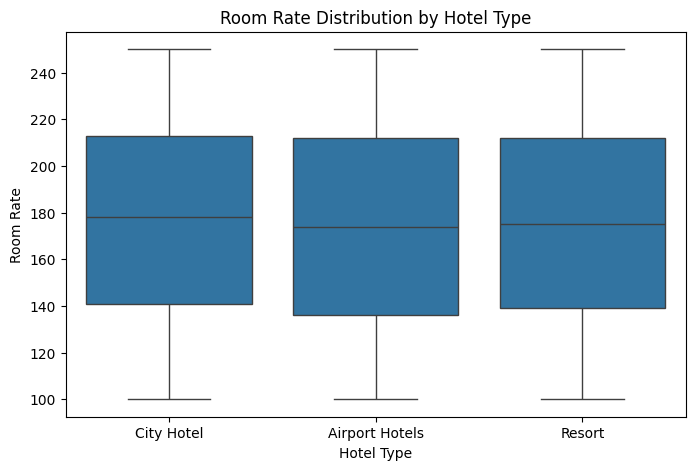

In [90]:
plt.figure(figsize=(8,5))
sns.boxplot(data=test_before, x="Hotel_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Room Rate")
plt.show()

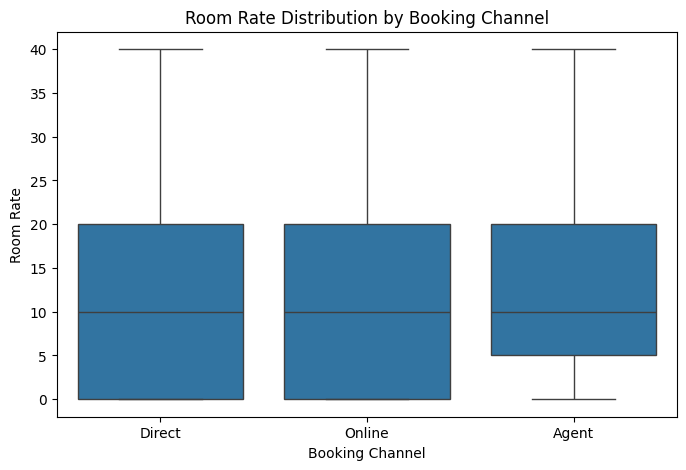

In [91]:
plt.figure(figsize=(8,5))
sns.boxplot(data=test_before, x="Booking_channel", y="Discount_Rate")
plt.title("Room Rate Distribution by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Room Rate")
plt.show()

### **Multivariate Analysis**

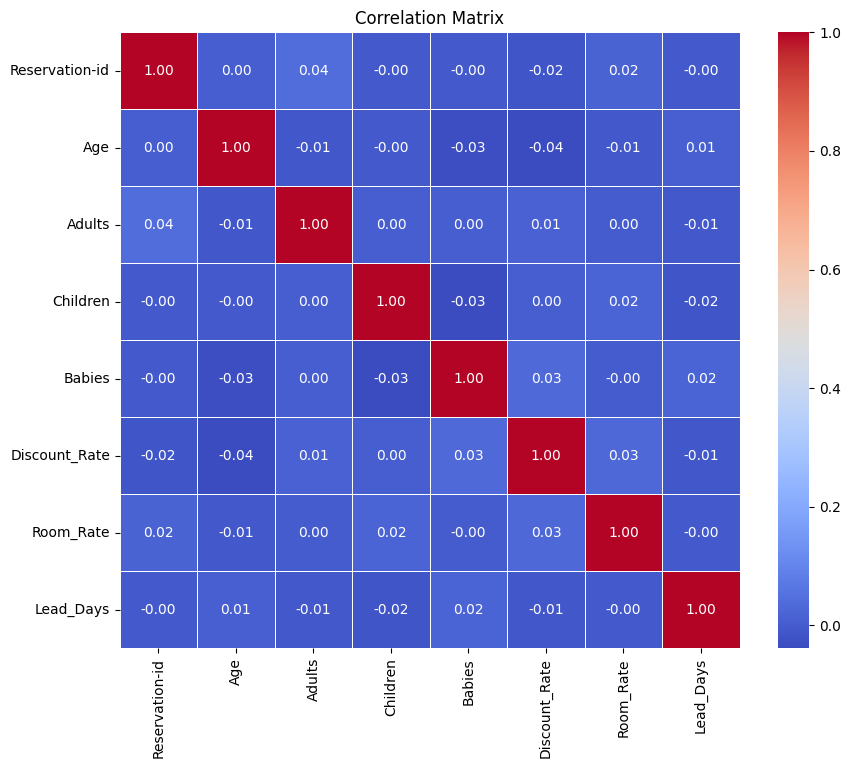

In [92]:
# Correlation Matrix
correlation_matrix_test = test_before.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_test, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

## **Data Cleaning**

In [93]:
import pandas as pd
import numpy as np

In [94]:
total_rows = test.shape[0]
num_duplicate_id_rows = dup_id.sum()
percentage_duplicate_ids = (num_duplicate_id_rows / total_rows) * 100

print(f"Total Number of rows: {total_rows}")
print(f"Number of rows with duplicate Reservation IDs: {num_duplicate_id_rows}")

Total Number of rows: 4318
Number of rows with duplicate Reservation IDs: 0


In [95]:
# Change data types
# Convert 'Expected_checkin', 'Expected_checkout' and 'Booking_date' to datetime objects
test['Expected_checkin'] = pd.to_datetime(test['Expected_checkin'])
test['Expected_checkout'] = pd.to_datetime(test['Expected_checkout'])
test['Booking_date'] = pd.to_datetime(test['Booking_date'])

In [96]:
# Standardize column names for easier feature work
test = test.rename(columns={'Reservation-id':'Reservation_id'})

In [97]:
# Calculate stay_nights
test['stay_nights'] = (test['Expected_checkout'] - test['Expected_checkin']).dt.days

# Calculate lead_time_days
test['Lead_Days'] = (test['Expected_checkin'] - test['Booking_date']).dt.days

# Calculate revenue
test['Revenue'] = test['stay_nights'] * test['Room_Rate']



In [98]:
# Impute negative 'Lead_Days' values to 0
test['Lead_Days'] = test['Lead_Days'].apply(lambda x: max(x, 0))

# Display descriptive statistics for 'Lead_Days' to confirm imputation
print(test['Lead_Days'].describe())

count    4318.000000
mean      109.805465
std        64.332939
min         0.000000
25%        54.000000
50%       109.000000
75%       165.000000
max       222.000000
Name: Lead_Days, dtype: float64


In [99]:

# Date parts for seasonality

test['Expected_checkin_year'] = test['Expected_checkin'].dt.year
test['Expected_checkin_month'] = test['Expected_checkin'].dt.month

In [100]:
# Binary mapping
binary_cols_test = [

    'Visted_Previously',
    'Previous_Cancellations',
    'Required_Car_Parking',
    'Use_Promotion'
]

for col in binary_cols_test:
    test[col] = test[col].map({'Yes':1, 'No':0})


In [101]:
binary_cols_test = [
    'Visted_Previously',
    'Previous_Cancellations',
    'Required_Car_Parking',
    'Use_Promotion'
]

for col in binary_cols_test:
    print(f"Value counts for '{col}':")
    print(test[col].value_counts())
    print("\n")

Value counts for 'Visted_Previously':
Visted_Previously
0    2867
1    1451
Name: count, dtype: int64


Value counts for 'Previous_Cancellations':
Previous_Cancellations
0    3872
1     446
Name: count, dtype: int64


Value counts for 'Required_Car_Parking':
Required_Car_Parking
1    3113
0    1205
Name: count, dtype: int64


Value counts for 'Use_Promotion':
Use_Promotion
1    3241
0    1077
Name: count, dtype: int64




In [102]:
test = test.drop(
    ['Expected_checkin', 'Expected_checkout', 'Booking_date'],
    axis=1
)

## **After Cleaning - Exploratory Data Analysis**

### **Univariate Analysis**

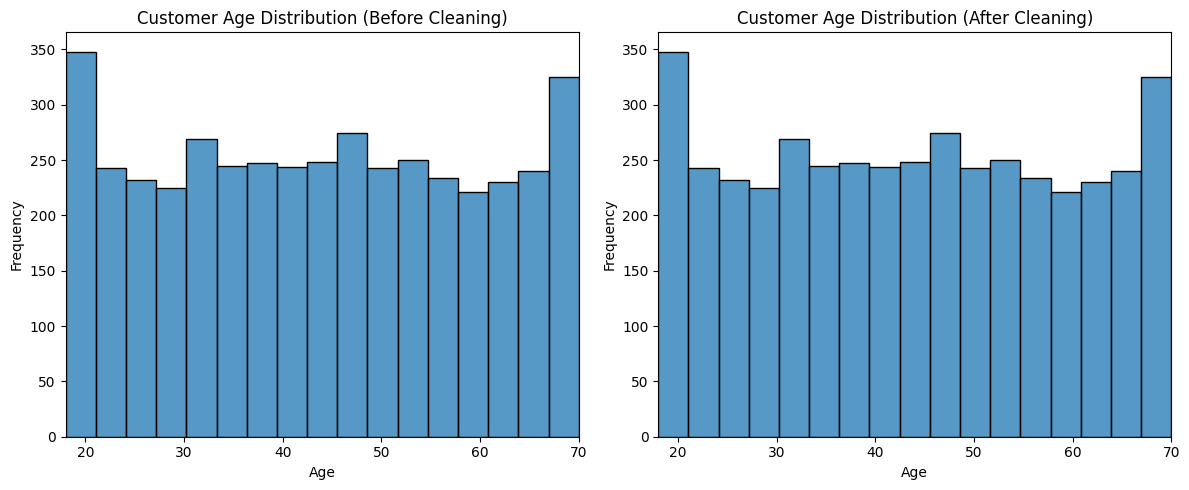

In [103]:
# Age Histogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(data=test_before, x="Age")
plt.title("Customer Age Distribution (Before Cleaning)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xlim(18, 70)

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(data=test, x="Age")
plt.title("Customer Age Distribution (After Cleaning)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xlim(18, 70)

plt.tight_layout()
plt.show()

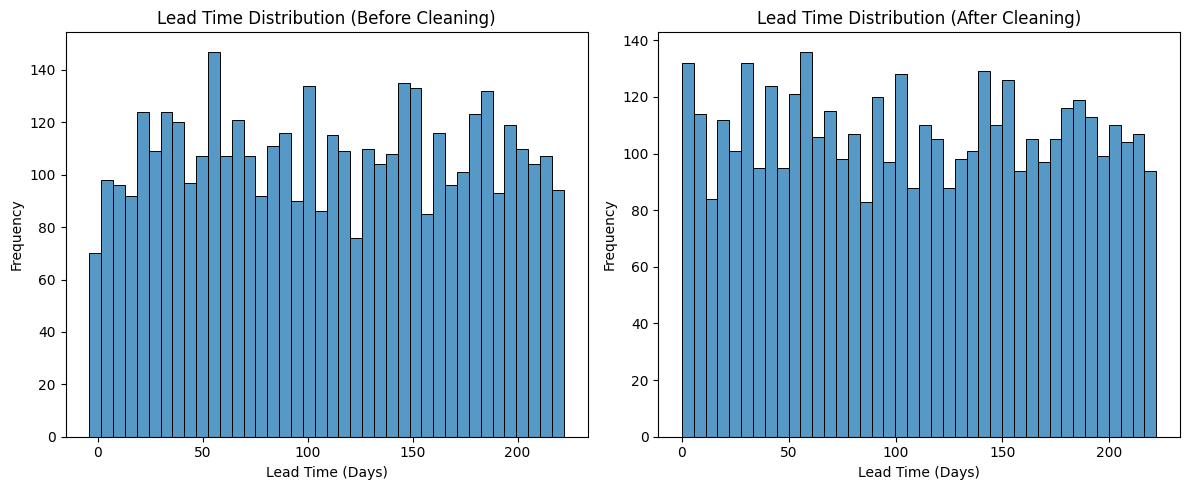

In [104]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(data=test_before, x="Lead_Days", bins=40)
plt.title("Lead Time Distribution (Before Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(data=test, x="Lead_Days", bins=40)
plt.title("Lead Time Distribution (After Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

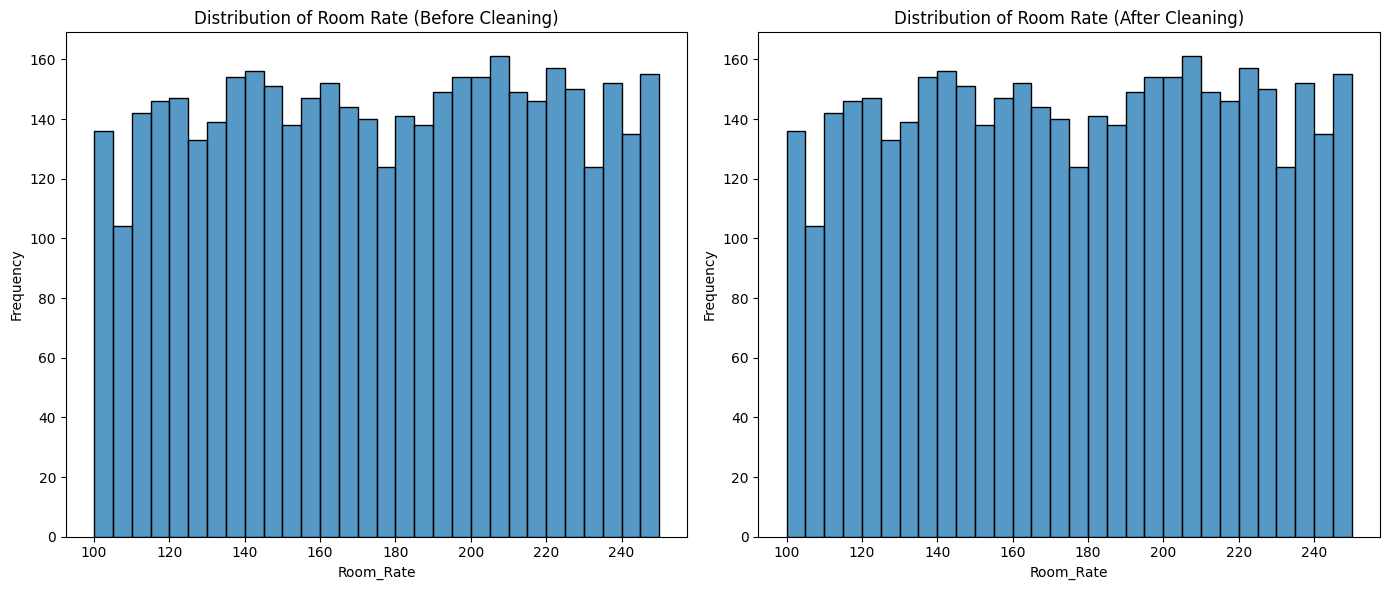

In [105]:
plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.histplot(data=test_before, x="Room_Rate", bins=30)
plt.title("Distribution of Room Rate (Before Cleaning)")
plt.xlabel("Room_Rate")
plt.ylabel("Frequency")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.histplot(data=test, x="Room_Rate", bins=30)
plt.title("Distribution of Room Rate (After Cleaning)")
plt.xlabel("Room_Rate")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

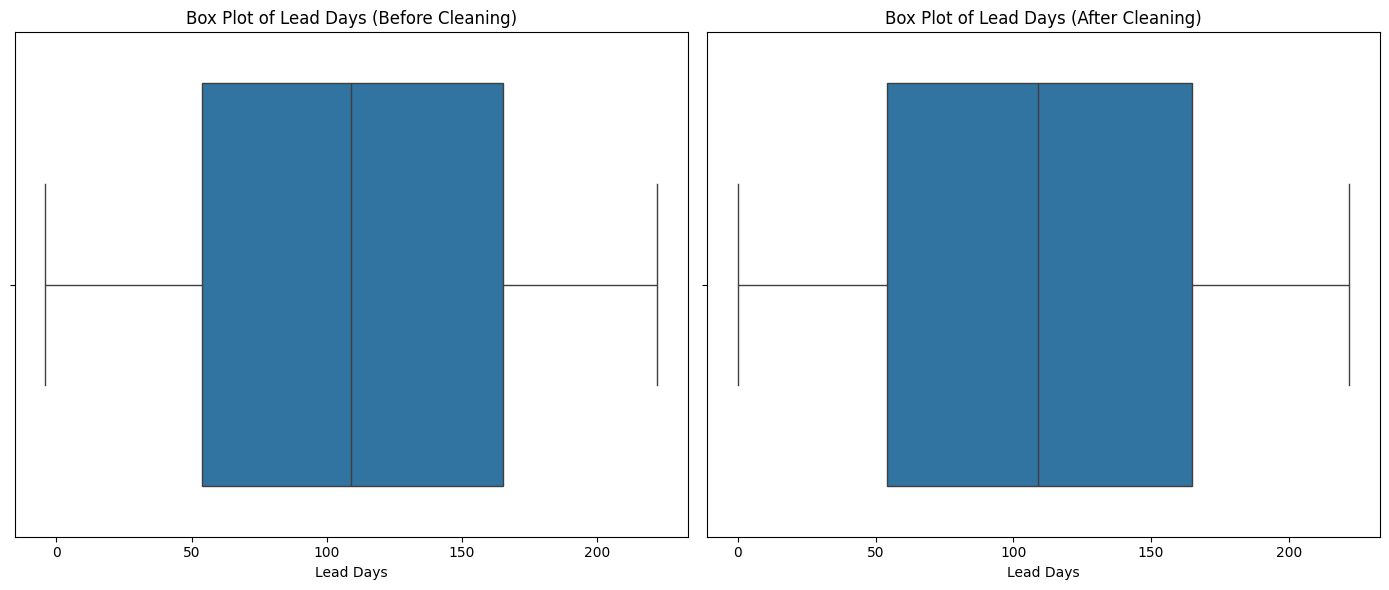

In [106]:
plt.figure(figsize=(14, 6))

# Box plot for original data (before cleaning)
plt.subplot(1, 2, 1)
sns.boxplot(x=test_before['Lead_Days'])
plt.title('Box Plot of Lead Days (Before Cleaning)')
plt.xlabel('Lead Days')

# Box plot for cleaned data (after cleaning)
plt.subplot(1, 2, 2)
sns.boxplot(x=test['Lead_Days'])
plt.title('Box Plot of Lead Days (After Cleaning)')
plt.xlabel('Lead Days')

plt.tight_layout()
plt.show()

/tmp/ipykernel_12567/2117854961.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_before, x="Room_Rate", palette="viridis")
/tmp/ipykernel_12567/2117854961.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test, x="Room_Rate", palette="viridis")


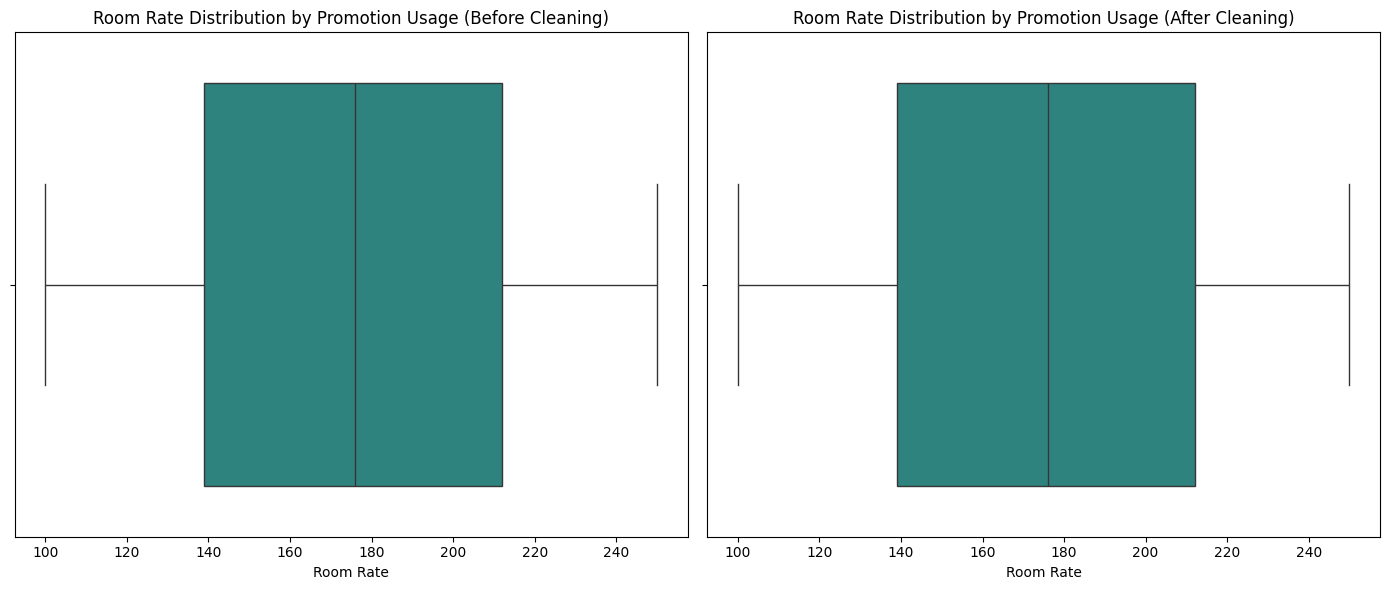

In [107]:
plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=test_before, x="Room_Rate", palette="viridis")
plt.title("Room Rate Distribution by Promotion Usage (Before Cleaning)")
plt.xlabel("Room Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=test, x="Room_Rate", palette="viridis")
plt.title("Room Rate Distribution by Promotion Usage (After Cleaning)")
plt.xlabel("Room Rate")

plt.tight_layout()
plt.show()

/tmp/ipykernel_12567/3396017088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_before, x="Discount_Rate", palette="plasma")
/tmp/ipykernel_12567/3396017088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test, x="Discount_Rate", palette="plasma")


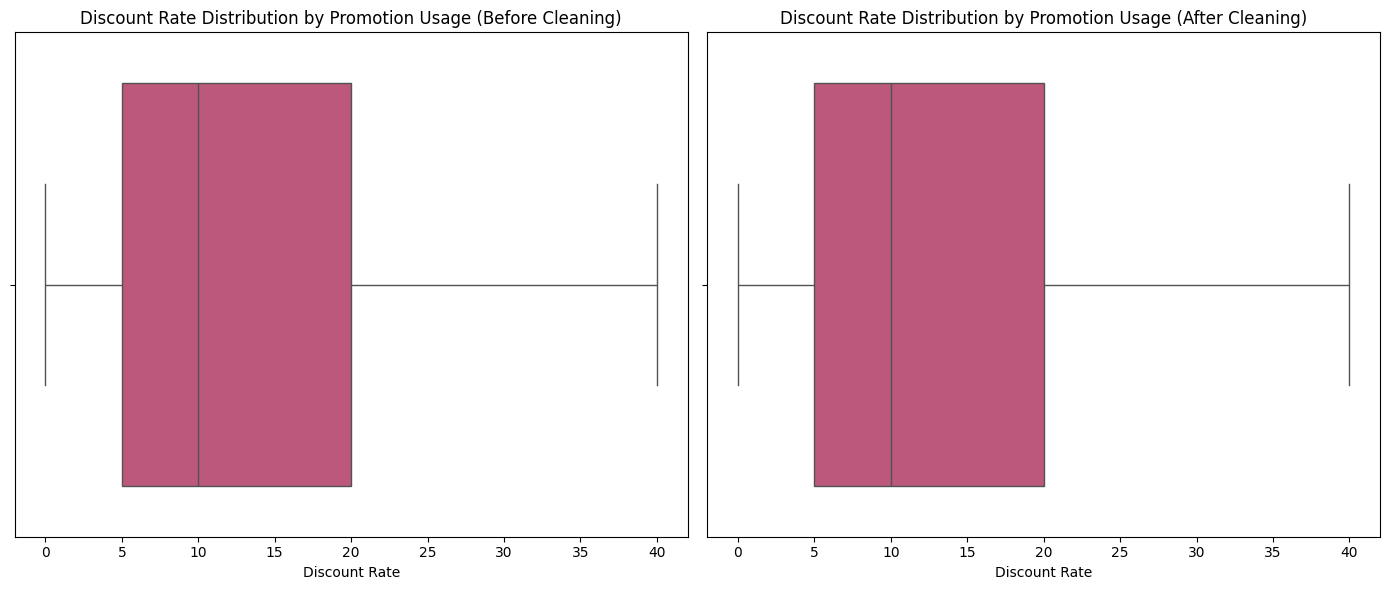

In [108]:
plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=test_before, x="Discount_Rate", palette="plasma")
plt.title("Discount Rate Distribution by Promotion Usage (Before Cleaning)")
plt.xlabel("Discount Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=test, x="Discount_Rate", palette="plasma")
plt.title("Discount Rate Distribution by Promotion Usage (After Cleaning)")
plt.xlabel("Discount Rate")

plt.tight_layout()
plt.show()

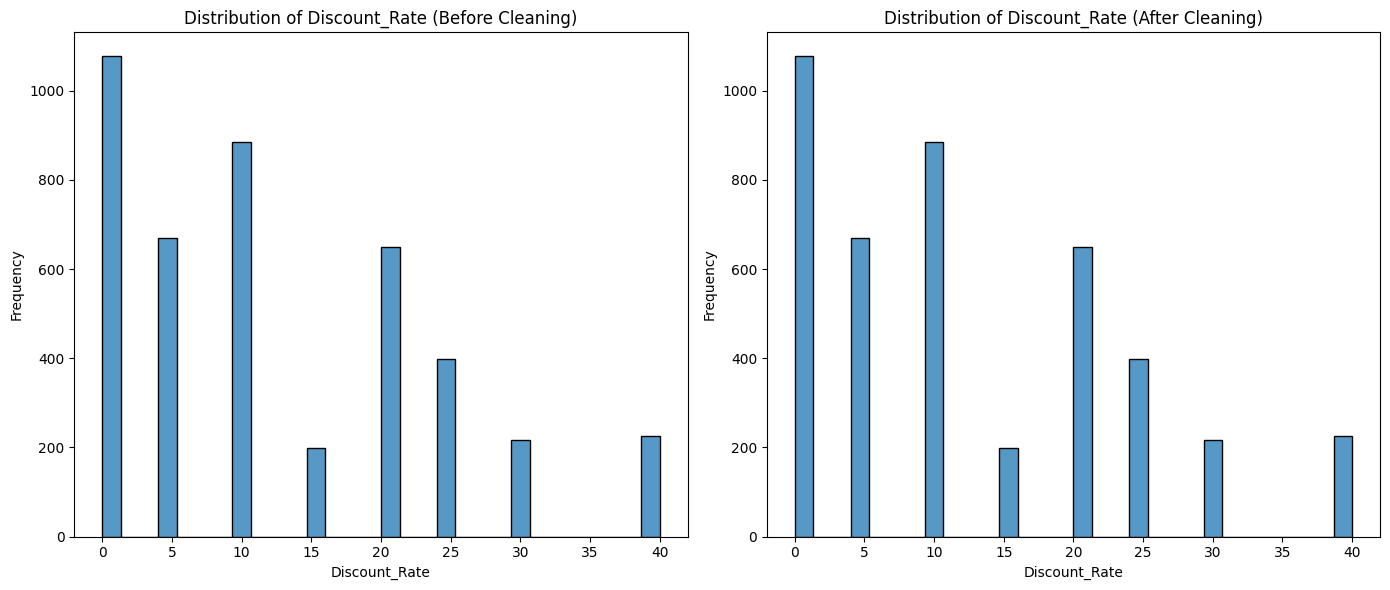

In [109]:
plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.histplot(data=test_before, x="Discount_Rate", bins=30)
plt.title("Distribution of Discount_Rate (Before Cleaning)")
plt.xlabel("Discount_Rate")
plt.ylabel("Frequency")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.histplot(data=test, x="Discount_Rate", bins=30)
plt.title("Distribution of Discount_Rate (After Cleaning)")
plt.xlabel("Discount_Rate")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### **Bivariate Analysis**

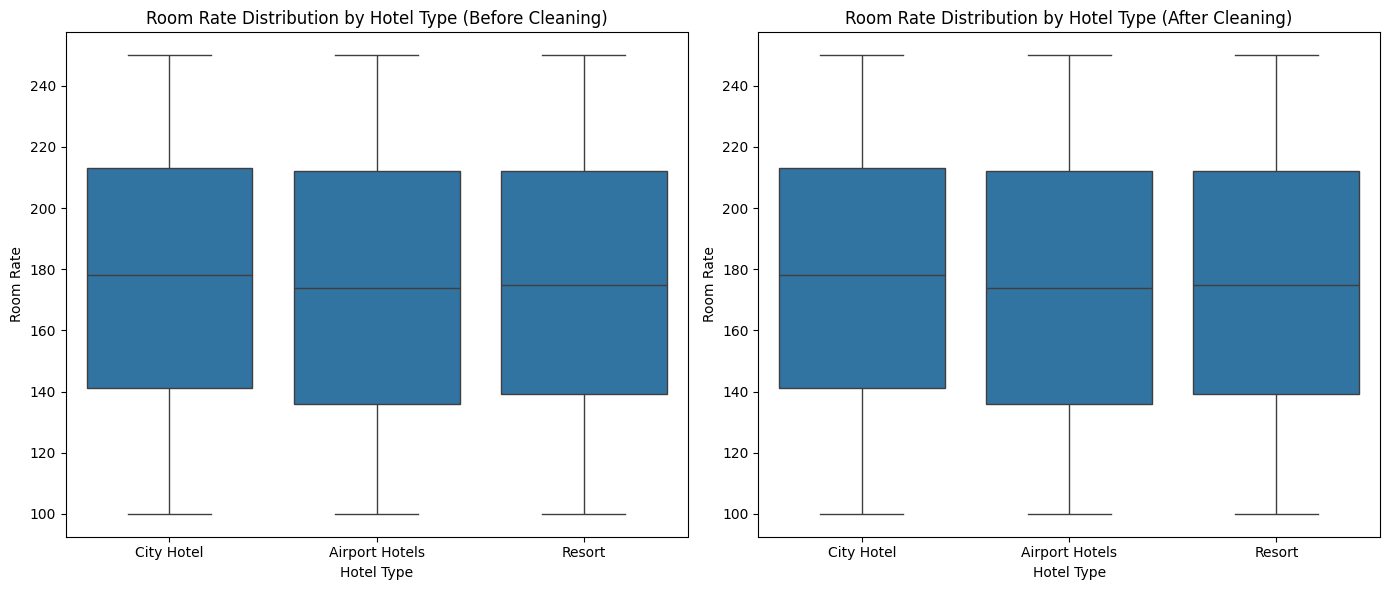

In [110]:
plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=test_before, x="Hotel_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Hotel Type (Before Cleaning)")
plt.xlabel("Hotel Type")
plt.ylabel("Room Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=test, x="Hotel_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Hotel Type (After Cleaning)")
plt.xlabel("Hotel Type")
plt.ylabel("Room Rate")

plt.tight_layout()
plt.show()

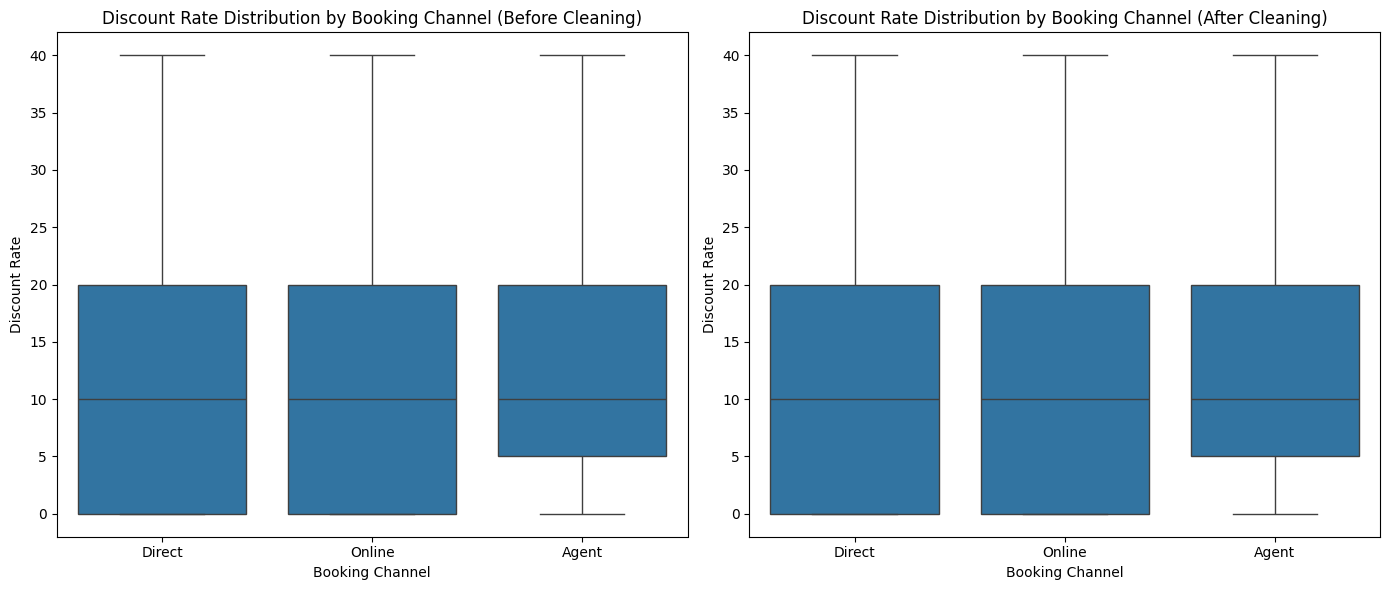

In [111]:
plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=test_before, x="Booking_channel", y="Discount_Rate")
plt.title("Discount Rate Distribution by Booking Channel (Before Cleaning)")
plt.xlabel("Booking Channel")
plt.ylabel("Discount Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=test, x="Booking_channel", y="Discount_Rate")
plt.title("Discount Rate Distribution by Booking Channel (After Cleaning)")
plt.xlabel("Booking Channel")
plt.ylabel("Discount Rate")

plt.tight_layout()
plt.show()

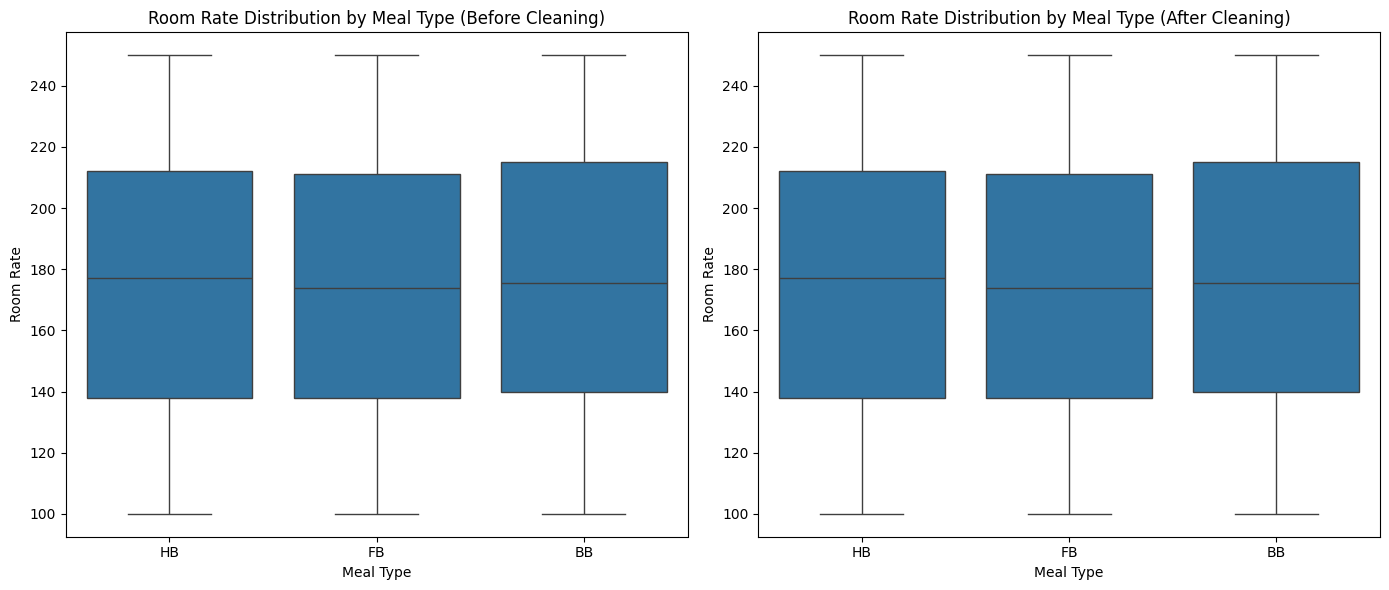

In [112]:
plt.figure(figsize=(14, 6))

# Plot for Original Data
plt.subplot(1, 2, 1)
sns.boxplot(data=test_before, x="Meal_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Meal Type (Before Cleaning)")
plt.xlabel("Meal Type")
plt.ylabel("Room Rate")

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
sns.boxplot(data=test, x="Meal_Type", y="Room_Rate")
plt.title("Room Rate Distribution by Meal Type (After Cleaning)")
plt.xlabel("Meal Type")
plt.ylabel("Room Rate")

plt.tight_layout()
plt.show()

### **Multivariate Analysis**

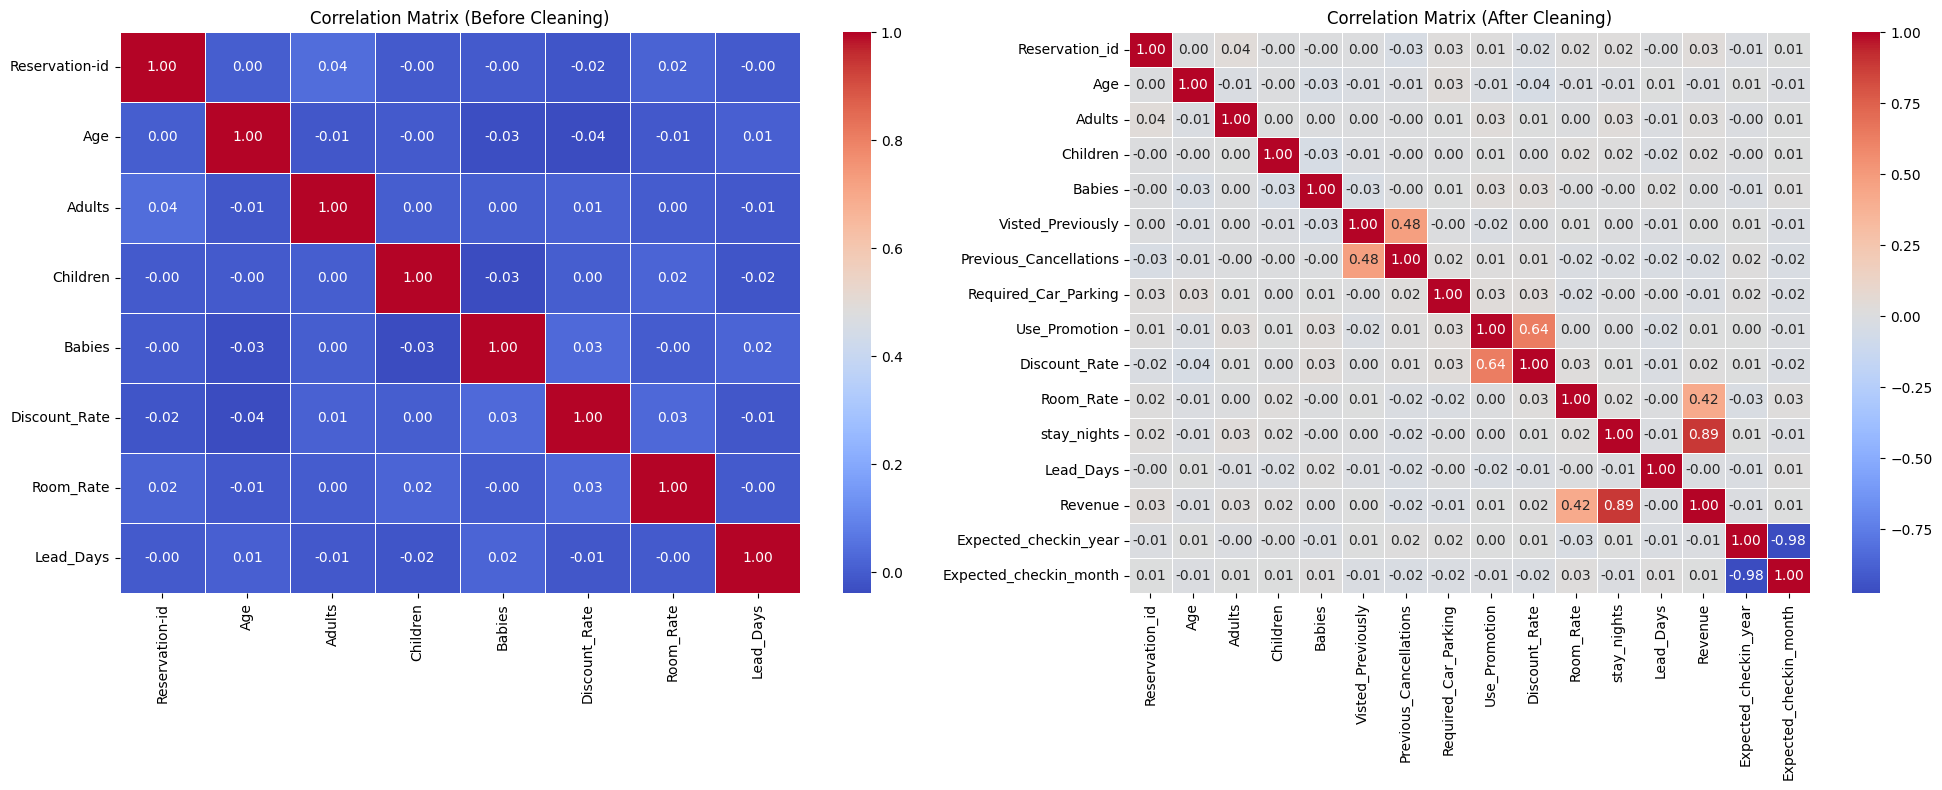

In [113]:
plt.figure(figsize=(20, 8))

# Plot for Original Data
plt.subplot(1, 2, 1)
correlation_matrix_test = test_before.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix_test, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix (Before Cleaning)')

# Plot for Cleaned Data
plt.subplot(1, 2, 2)
correlation_matrix_test = test.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix_test, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix (After Cleaning)')

plt.tight_layout()
plt.show()

## **Exporting cleaned data**

In [114]:
test.to_csv('/content/drive/MyDrive/Hotel Revenue Prediction GCW/cleaned_test.csv', index=False)

# **Hotel 'A'- validation Dataset**

## **Data Exploration**

In [115]:
#Reading the CSV files
valid = pd.read_csv('/content/drive/MyDrive/Hotel Revenue Prediction GCW/Hotel-A-validation.csv')

In [116]:
#Load dataset
valid

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,45716350,M,56,caucasian,Grad,<25K,West,Resort,8/31/2016,9/2/2016,...,HB,No,No,No Deposit,Agent,No,No-Show,Yes,15,192
1,88857401,M,60,Latino,College,25K --50K,West,Resort,8/31/2016,9/4/2016,...,FB,Yes,No,No Deposit,Online,Yes,Canceled,No,0,187
2,16074440,F,58,Asian American,College,<25K,North,Airport Hotels,9/1/2016,9/2/2016,...,FB,No,No,No Deposit,Direct,No,Canceled,Yes,10,227
3,10992124,F,23,Latino,College,25K --50K,East,Airport Hotels,8/31/2016,9/2/2016,...,FB,Yes,No,Refundable,Direct,No,Check-In,Yes,25,189
4,15934351,F,47,Asian American,College,25K --50K,South,City Hotel,8/31/2016,9/1/2016,...,HB,Yes,No,No Deposit,Online,Yes,Check-In,Yes,10,218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2744,32194836,F,22,caucasian,College,50K -- 100K,South,Resort,11/18/2016,11/21/2016,...,BB,Yes,No,Refundable,Online,No,Check-In,Yes,10,199
2745,52215692,F,35,caucasian,College,25K --50K,South,Airport Hotels,12/9/2016,12/10/2016,...,FB,No,No,Non-Refundable,Direct,Yes,Canceled,Yes,5,106
2746,31908733,M,18,Asian American,Grad,25K --50K,North,Resort,11/18/2016,11/20/2016,...,FB,No,No,Refundable,Agent,No,No-Show,Yes,20,136
2747,41776403,M,42,Asian American,College,<25K,West,City Hotel,11/18/2016,11/19/2016,...,HB,Yes,Yes,No Deposit,Online,Yes,Check-In,Yes,20,226


In [117]:
#No. of rows and columns in dataset
print(valid.shape)

(2749, 24)


In [118]:
#Data types of each column in  dataset
valid.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,object
Expected_checkout,object


In [119]:
# Convert 'Expected_checkin', 'Expected_checkout' and 'Booking_date' to datetime objects
valid['Expected_checkin'] = pd.to_datetime(valid['Expected_checkin'])
valid['Expected_checkout'] = pd.to_datetime(valid['Expected_checkout'])
valid['Booking_date'] = pd.to_datetime(valid['Booking_date'])

In [120]:
valid.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,datetime64[ns]
Expected_checkout,datetime64[ns]


In [121]:
#identify the missing data
print(valid.isnull().sum())

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Reservation_Status        0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64


In [122]:
#Descriptive statistics for numeric attributes
valid.describe().T

,count,mean,min,25%,50%,75%,max,std
Reservation-id,2749.0,49918271.804656,143.0,24843132.0,49328761.0,74712969.0,99988487.0,28880113.934245
Age,2749.0,44.196799,18.0,31.0,44.0,57.0,70.0,15.212212
Expected_checkin,2749,2016-10-16 17:37:04.954528768,2016-08-31 00:00:00,2016-09-25 00:00:00,2016-10-14 00:00:00,2016-11-02 00:00:00,2017-09-09 00:00:00,NaN
Expected_checkout,2749,2016-10-18 12:45:18.661331456,2016-09-01 00:00:00,2016-09-26 00:00:00,2016-10-16 00:00:00,2016-11-03 00:00:00,2017-09-13 00:00:00,NaN
Booking_date,2749,2016-06-28 23:46:22.830120192,2016-01-26 00:00:00,2016-04-30 00:00:00,2016-06-28 00:00:00,2016-08-26 00:00:00,2017-08-02 00:00:00,NaN
Adults,2749.0,2.33685,1.0,1.0,2.0,3.0,5.0,1.185808
Children,2749.0,1.740633,1.0,1.0,2.0,2.0,3.0,0.724913
Babies,2749.0,0.33394,0.0,0.0,0.0,1.0,2.0,0.566997
Discount_Rate,2749.0,12.48454,0.0,5.0,10.0,20.0,40.0,11.166182
Room_Rate,2749.0,173.742452,100.0,136.0,173.0,212.0,250.0,43.880178


In [123]:
#Descriptive statistics for non-numeric attributes
valid.describe(include=['object']).T

,count,unique,top,freq
Gender,2749,2,F,1396
Ethnicity,2749,4,caucasian,697
Educational_Level,2749,4,College,1124
Income,2749,4,50K -- 100K,786
Country_region,2749,4,South,1093
Hotel_Type,2749,3,Airport Hotels,976
Meal_Type,2749,3,FB,937
Visted_Previously,2749,2,No,1791
Previous_Cancellations,2749,2,No,2421
Deposit_type,2749,3,No Deposit,1843


In [124]:
from os import dup
# whole‑row duplicates
dup_row = valid.duplicated(keep=False)
duplicates = valid[dup_row]
print("Total duplicate rows:", dup_row.sum())

Total duplicate rows: 0


In [125]:
# Duplicates on a particular key
dup_id = valid['Reservation-id'].duplicated(keep=False)
print("Rows sharing the same Reservation ID:", dup_id.sum())
dup_by_id = valid[dup_id]


Rows sharing the same Reservation ID: 0


In [126]:
#Identifying unique values
unique_values_valid = valid.apply(pd.Series.unique)
print(unique_values_valid)

Reservation-id            [45716350, 88857401, 16074440, 10992124, 15934...
Gender                                                               [M, F]
Age                       [56, 60, 58, 23, 47, 59, 48, 32, 57, 38, 46, 2...
Ethnicity                 [caucasian, Latino, Asian American, African Am...
Educational_Level                  [Grad, College, High-School, Mid-School]
Income                                [<25K, 25K --50K, 50K -- 100K, >100K]
Country_region                                   [West, North, East, South]
Hotel_Type                             [Resort, Airport Hotels, City Hotel]
Expected_checkin          [2016-08-31 00:00:00, 2016-09-01 00:00:00, 201...
Expected_checkout         [2016-09-02 00:00:00, 2016-09-04 00:00:00, 201...
Booking_date              [2016-02-18 00:00:00, 2016-03-09 00:00:00, 201...
Adults                                                      [2, 3, 1, 4, 5]
Children                                                          [2, 1, 3]
Babies      

### **Before Cleaning- Exploratory Data Analysis**

In [127]:
valid_before = valid.copy()

,Expected_checkin,Booking_date,Lead_Days
0,2016-08-31,2016-02-18,195
1,2016-08-31,2016-03-09,175
2,2016-09-01,2016-02-21,193
3,2016-08-31,2016-05-20,103
4,2016-08-31,2016-05-31,92


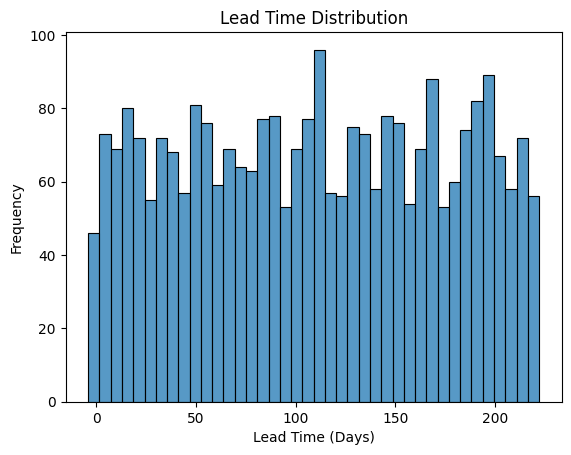

In [128]:
# Convert 'Expected_checkin' and 'Booking_date' to datetime objects
valid_before['Expected_checkin'] = pd.to_datetime(valid_before['Expected_checkin'])
valid_before['Booking_date'] = pd.to_datetime(valid_before['Booking_date'])

# Calculate Lead_Days
valid_before['Lead_Days'] = (valid_before['Expected_checkin'] - valid_before['Booking_date']).dt.days

# Display the first few rows with the new 'Lead_Days' column
display(valid_before[['Expected_checkin', 'Booking_date', 'Lead_Days']].head())

# Lead Time Histogram
plt.figure()
sns.histplot(data=valid_before, x="Lead_Days", bins=40)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

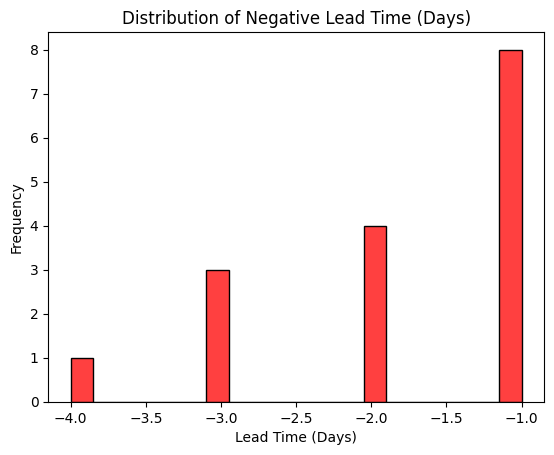

In [129]:
# Filter for negative Lead_Days
negative_lead_days_valid = valid_before[valid_before['Lead_Days'] < 0]

# Histogram for negative Lead_Days
plt.figure()
sns.histplot(data=negative_lead_days_valid, x="Lead_Days", bins=20, color='red')
plt.title("Distribution of Negative Lead Time (Days)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

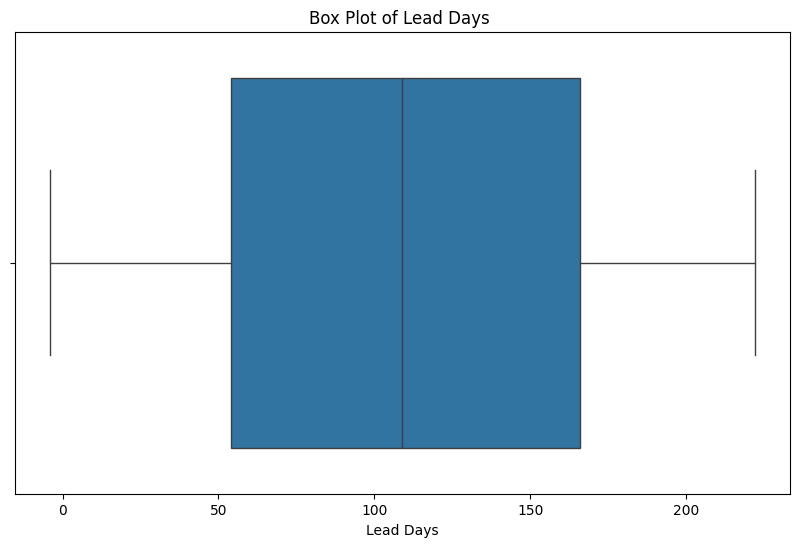

In [130]:
# Box plot to identify outliers in Lead_Days
plt.figure(figsize=(10, 6))
sns.boxplot(x=valid_before['Lead_Days'])
plt.title('Box Plot of Lead Days ')
plt.xlabel('Lead Days')
plt.show()

## **Data Cleaning**

In [131]:
total_rows = valid.shape[0]
num_duplicate_id_rows = dup_id.sum()
percentage_duplicate_ids = (num_duplicate_id_rows / total_rows) * 100

print(f"Total Number of rows: {total_rows}")
print(f"Number of rows with duplicate Reservation IDs: {num_duplicate_id_rows}")
print(f"Percentage of rows with duplicate Reservation IDs: {percentage_duplicate_ids:.2f}%")

Total Number of rows: 2749
Number of rows with duplicate Reservation IDs: 0
Percentage of rows with duplicate Reservation IDs: 0.00%


In [132]:
# Display counts before standardization
print(valid ['Reservation_Status'].value_counts())

Reservation_Status
Check-In    1610
Canceled     741
No-Show      398
Name: count, dtype: int64


In [133]:
# Change data types
# Convert 'Expected_checkin', 'Expected_checkout' and 'Booking_date' to datetime objects
valid['Expected_checkin'] = pd.to_datetime(valid['Expected_checkin'])
valid['Expected_checkout'] = pd.to_datetime(valid['Expected_checkout'])
valid['Booking_date'] = pd.to_datetime(valid['Booking_date'])

In [134]:
# Standardize column names for easier feature work
valid = valid.rename(columns={'Reservation-id':'Reservation_id'})

In [135]:
# Calculate stay_nights
valid['stay_nights'] = (valid['Expected_checkout'] - valid['Expected_checkin']).dt.days

# Calculate lead_time_days
valid['Lead_Days'] = (valid['Expected_checkin'] - valid['Booking_date']).dt.days

# Calculate revenue
valid['Revenue'] = valid['stay_nights'] * valid['Room_Rate']

In [136]:
# Impute negative 'Lead_Days' values to 0
valid['Lead_Days'] = valid['Lead_Days'].apply(lambda x: max(x, 0))

# Display descriptive statistics for 'Lead_Days' to confirm imputation
print(valid['Lead_Days'].describe())

count    2749.000000
mean      109.754092
std        64.623683
min         0.000000
25%        54.000000
50%       109.000000
75%       166.000000
max       222.000000
Name: Lead_Days, dtype: float64


In [137]:
# Date parts for seasonality
valid['Expected_checkin_year'] = valid['Expected_checkin'].dt.year
valid['Expected_checkin_month'] = valid['Expected_checkin'].dt.month

In [138]:
# Binary mapping
binary_cols_valid = [

    'Visted_Previously',
    'Previous_Cancellations',
    'Required_Car_Parking',
    'Use_Promotion'
]

for col in binary_cols_valid:
    valid[col] = valid[col].map({'Yes':1, 'No':0})

In [139]:
binary_cols_valid = [
    'Visted_Previously',
    'Previous_Cancellations',
    'Required_Car_Parking',
    'Use_Promotion'
]

for col in binary_cols_valid:
    print(f"Value counts for '{col}':")
    print(valid[col].value_counts())
    print("\n")

Value counts for 'Visted_Previously':
Visted_Previously
0    1791
1     958
Name: count, dtype: int64


Value counts for 'Previous_Cancellations':
Previous_Cancellations
0    2421
1     328
Name: count, dtype: int64


Value counts for 'Required_Car_Parking':
Required_Car_Parking
1    1959
0     790
Name: count, dtype: int64


Value counts for 'Use_Promotion':
Use_Promotion
1    2085
0     664
Name: count, dtype: int64




In [140]:
status_mapping = {
    'Check-In':1,
    'Canceled':2,
    'No-Show':3,

}

valid['Reservation_Status'] = valid['Reservation_Status'].map(status_mapping)


In [141]:
print(valid['Reservation_Status'].value_counts())

Reservation_Status
1    1610
2     741
3     398
Name: count, dtype: int64


In [142]:
valid = valid.drop(
    ['Expected_checkin', 'Expected_checkout', 'Booking_date'],
    axis=1
)

### **After Cleaning - Exploratory Data Analysis**

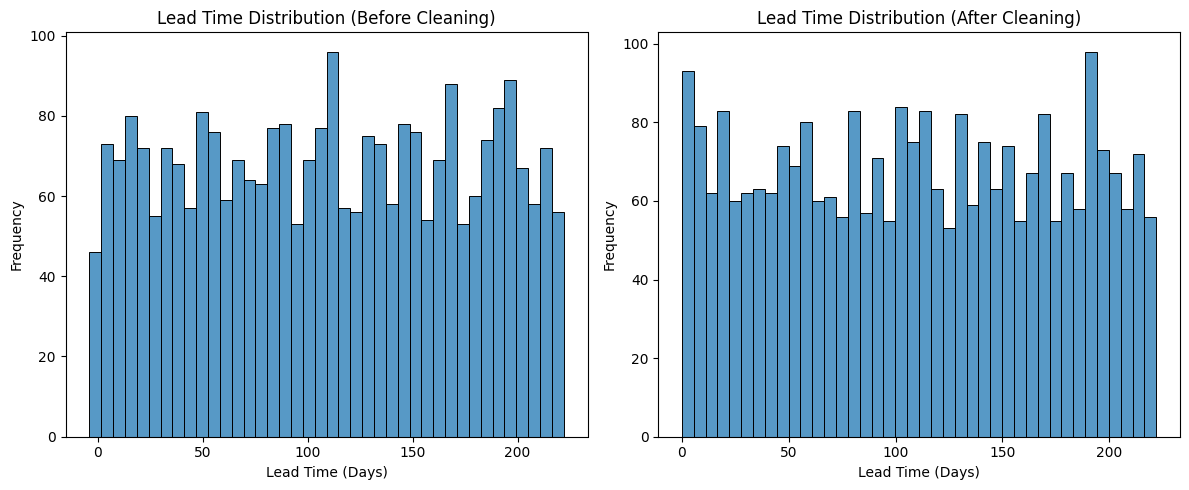

In [143]:
# Ensure date columns are datetime objects in the original DataFrame for Lead_Days calculation
valid_before['Expected_checkin'] = pd.to_datetime(valid_before['Expected_checkin'])
valid_before['Booking_date'] = pd.to_datetime(valid_before['Booking_date'])
valid_before['Lead_Days'] = (valid_before['Expected_checkin'] - valid_before['Booking_date']).dt.days

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(data=valid_before, x="Lead_Days", bins=40)
plt.title("Lead Time Distribution (Before Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(data=valid, x="Lead_Days", bins=40)
plt.title("Lead Time Distribution (After Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

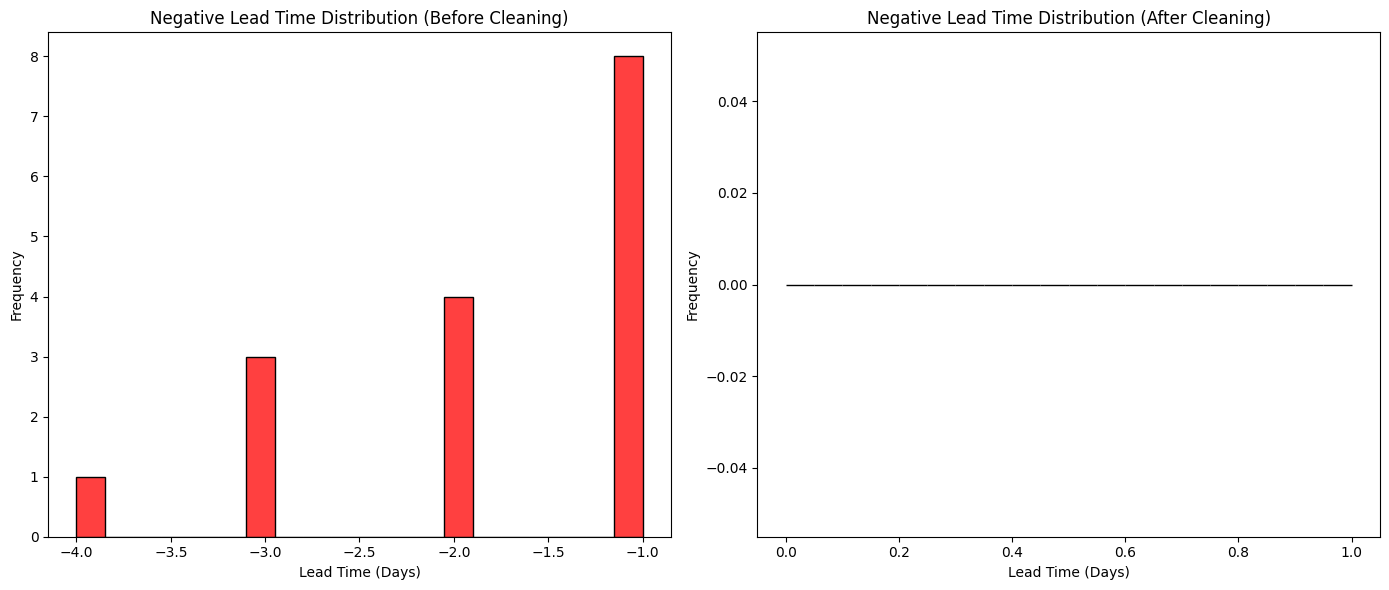

In [144]:

# Convert date columns to datetime for original dataset to calculate Lead_Days
valid_before['Expected_checkin'] = pd.to_datetime(valid_before['Expected_checkin'])
valid_before['Booking_date'] = pd.to_datetime(valid_before['Booking_date'])
valid_before['Lead_Days'] = (valid_before['Expected_checkin'] - valid_before['Booking_date']).dt.days

# Filter for negative Lead_Days in the original dataset
negative_lead_days_valid = valid_before[valid_before['Lead_Days'] < 0]

# Filter for negative Lead_Days in the cleaned dataset (should be empty after imputation to 0)
negative_lead_days_cleaned_valid = valid[valid['Lead_Days'] < 0]

plt.figure(figsize=(14, 6))

# Plot for Original Data (before imputation)
plt.subplot(1, 2, 1)
sns.histplot(data=negative_lead_days_valid, x="Lead_Days", bins=20, color='red')
plt.title("Negative Lead Time Distribution (Before Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

# Plot for Cleaned Data (after imputation)
plt.subplot(1, 2, 2)
sns.histplot(data=negative_lead_days_cleaned_valid, x="Lead_Days", bins=20, color='red')
plt.title("Negative Lead Time Distribution (After Cleaning)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

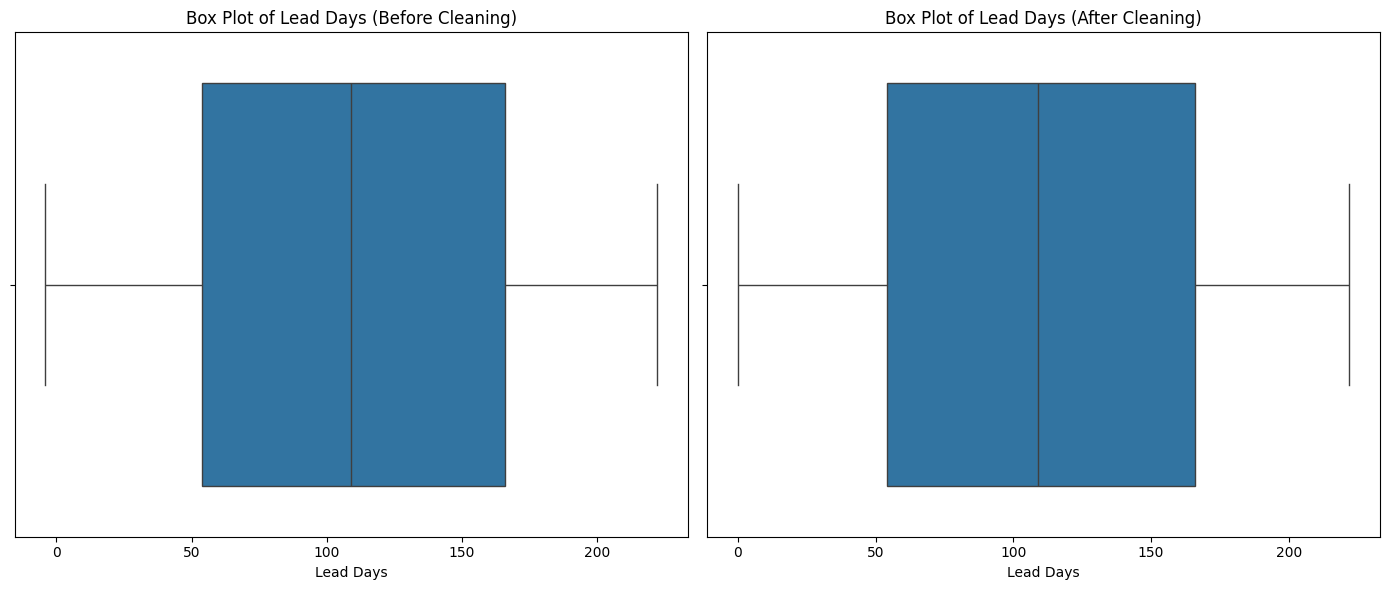

In [145]:
plt.figure(figsize=(14, 6))

# Box plot for original data (before cleaning)
plt.subplot(1, 2, 1)
sns.boxplot(x=valid_before['Lead_Days'])
plt.title('Box Plot of Lead Days (Before Cleaning)')
plt.xlabel('Lead Days')

# Box plot for cleaned data (after cleaning)
plt.subplot(1, 2, 2)
sns.boxplot(x=valid['Lead_Days'])
plt.title('Box Plot of Lead Days (After Cleaning)')
plt.xlabel('Lead Days')

plt.tight_layout()
plt.show()

# **Exporting cleaned data**

In [146]:
valid.to_csv('//content/drive/MyDrive/Hotel Revenue Prediction GCW/valid_cleaned.csv', index=False)

# **Revenue Loss Analysis**

### Compute Revenue & Identify Lost Revenue

> **Revenue = stay_nights × Room_Rate**  
> Lost revenue = revenue from bookings where Reservation_Status is Cancelled (2) or No-Show (3)

In [147]:
# Ensure Revenue column exists (recalculate if needed)
if 'Revenue' not in Historical_train.columns:
    Historical_train['Revenue'] = Historical_train['stay_nights'] * Historical_train['Room_Rate']

# Reservation_Status mapping reference:
# 1 = Check-In / Check-Out, 2 = Canceled, 3 = No-Show
lost = Historical_train[Historical_train['Reservation_Status'].isin([2, 3])].copy()
checked_in = Historical_train[Historical_train['Reservation_Status'] == 1].copy()

total_revenue_all      = Historical_train['Revenue'].sum()
total_revenue_lost     = lost['Revenue'].sum()
total_revenue_realised = checked_in['Revenue'].sum()
loss_pct               = (total_revenue_lost / total_revenue_all) * 100

print(f"Total potential revenue  : £{total_revenue_all:,.0f}")
print(f"Revenue realised         : £{total_revenue_realised:,.0f}")
print(f"Total revenue LOST       : £{total_revenue_lost:,.0f}")
print(f"Loss as % of potential   : {loss_pct:.1f}%")
print()

# Split by cancellation vs no-show
cancel_loss  = Historical_train[Historical_train['Reservation_Status'] == 2]['Revenue'].sum()
noshow_loss  = Historical_train[Historical_train['Reservation_Status'] == 3]['Revenue'].sum()
print(f" Cancellations        : £{cancel_loss:,.0f}")
print(f" No-Shows             : £{noshow_loss:,.0f}")

Total potential revenue  : £8,826,348
Revenue realised         : £6,822,269
Total revenue LOST       : £2,004,079
Loss as % of potential   : 22.7%

 Cancellations        : £1,325,887
 No-Shows             : £678,192


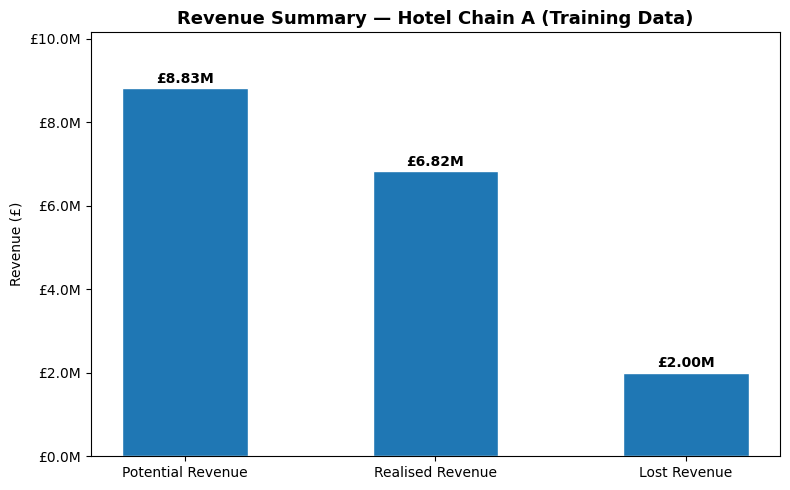

In [148]:
import matplotlib.ticker as mtick
# Waterfall-style summary bar chart
labels  = ['Potential Revenue', 'Realised Revenue', 'Lost Revenue']
values  = [total_revenue_all, total_revenue_realised, total_revenue_lost]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, edgecolor='white', width=0.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'£{val/1e6:.2f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Revenue Summary — Hotel Chain A (Training Data)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.set_ylim(0, total_revenue_all * 1.15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_12567/1369412095.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loss_by_hotel, x='Hotel_Type', y='Revenue_Lost', palette='Reds_r', ax=axes[0])


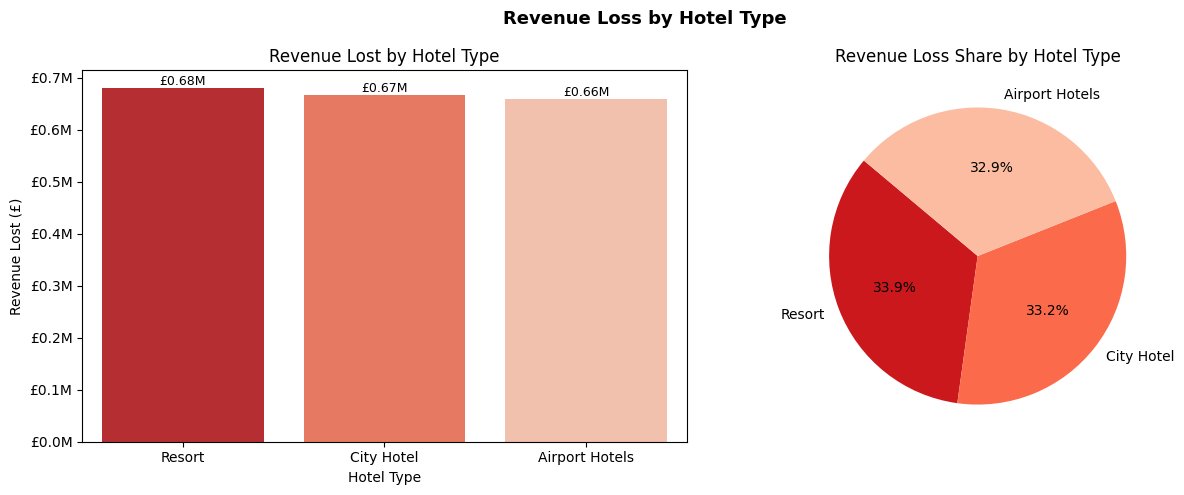

    Hotel_Type  Revenue_Lost
        Resort        679888
    City Hotel        665768
Airport Hotels        658423


In [149]:
import matplotlib.ticker as mtick
# Re-attach Hotel_Type to lost df (it survives encoding only in train)
loss_by_hotel = lost.groupby('Hotel_Type')['Revenue'].sum().sort_values(ascending=False).reset_index()
loss_by_hotel.columns = ['Hotel_Type', 'Revenue_Lost']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
sns.barplot(data=loss_by_hotel, x='Hotel_Type', y='Revenue_Lost', palette='Reds_r', ax=axes[0])
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[0].set_title('Revenue Lost by Hotel Type')
axes[0].set_xlabel('Hotel Type')
axes[0].set_ylabel('Revenue Lost (£)')
for p in axes[0].patches:
    axes[0].annotate(f'£{p.get_height()/1e6:.2f}M',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(loss_by_hotel['Revenue_Lost'], labels=loss_by_hotel['Hotel_Type'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Reds_r', len(loss_by_hotel)))
axes[1].set_title('Revenue Loss Share by Hotel Type')

plt.suptitle('Revenue Loss by Hotel Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(loss_by_hotel.to_string(index=False))

/tmp/ipykernel_12567/292961647.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loss_by_region, x='Country_region', y='Revenue_Lost',
/tmp/ipykernel_12567/292961647.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loss_by_region, x='Country_region', y='Bookings_Lost',


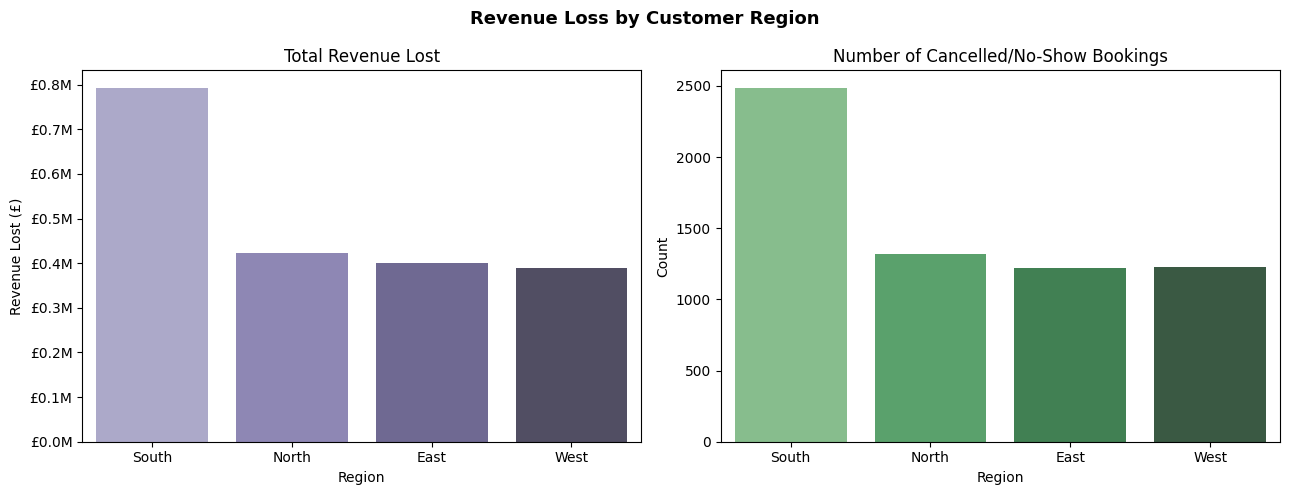

Country_region  Revenue_Lost  Bookings_Lost
         South        792308           2485
         North        421910           1321
          East        399820           1222
          West        390041           1228


In [150]:
#  Country Region analysis
loss_by_region = lost.groupby('Country_region').agg(
    Revenue_Lost=('Revenue', 'sum'),
    Bookings_Lost=('Revenue', 'count'),
).sort_values('Revenue_Lost', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Total revenue lost
sns.barplot(data=loss_by_region, x='Country_region', y='Revenue_Lost',
            palette='Purples_d', ax=axes[0])
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[0].set_title('Total Revenue Lost')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Revenue Lost (£)')

# Number of lost bookings
sns.barplot(data=loss_by_region, x='Country_region', y='Bookings_Lost',
            palette='Greens_d', ax=axes[1])
axes[1].set_title('Number of Cancelled/No-Show Bookings')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Count')

plt.suptitle('Revenue Loss by Customer Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(loss_by_region.to_string(index=False))

/tmp/ipykernel_12567/1032315723.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loss_by_income, x='Income', y='Revenue_Lost',


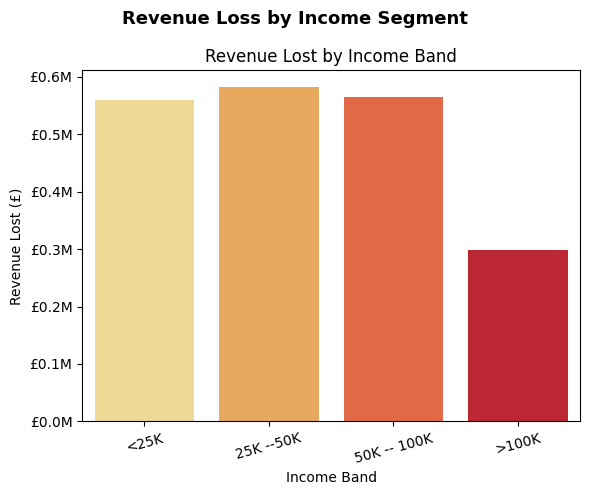

In [151]:
#  Income segment analysis
income_order = ['<25K', '25K --50K', '50K -- 100K', '>100K']

loss_by_income = lost.groupby('Income').agg(
    Revenue_Lost=('Revenue', 'sum'),
).reindex(income_order).reset_index()

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

sns.barplot(data=loss_by_income, x='Income', y='Revenue_Lost',
            palette='YlOrRd', ax=ax)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.set_title('Revenue Lost by Income Band')
ax.set_xlabel('Income Band')
ax.set_ylabel('Revenue Lost (£)')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('Revenue Loss by Income Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_12567/3955523294.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loss_by_ethnicity, x='Ethnicity', y='Revenue', palette='coolwarm', ax=ax)


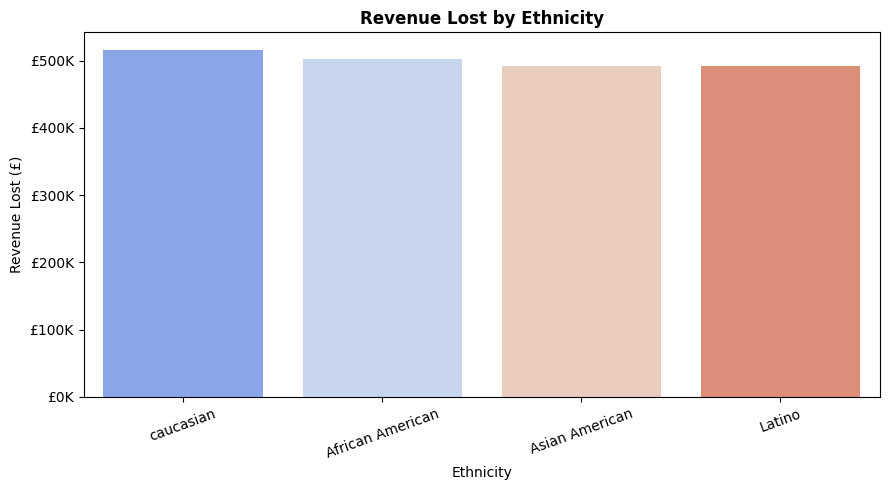

In [152]:
#  Ethnicity analysis
loss_by_ethnicity = lost.groupby('Ethnicity')['Revenue'].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=loss_by_ethnicity, x='Ethnicity', y='Revenue', palette='coolwarm', ax=ax)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
ax.set_title('Revenue Lost by Ethnicity', fontsize=12, fontweight='bold')
ax.set_xlabel('Ethnicity')
ax.set_ylabel('Revenue Lost (£)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

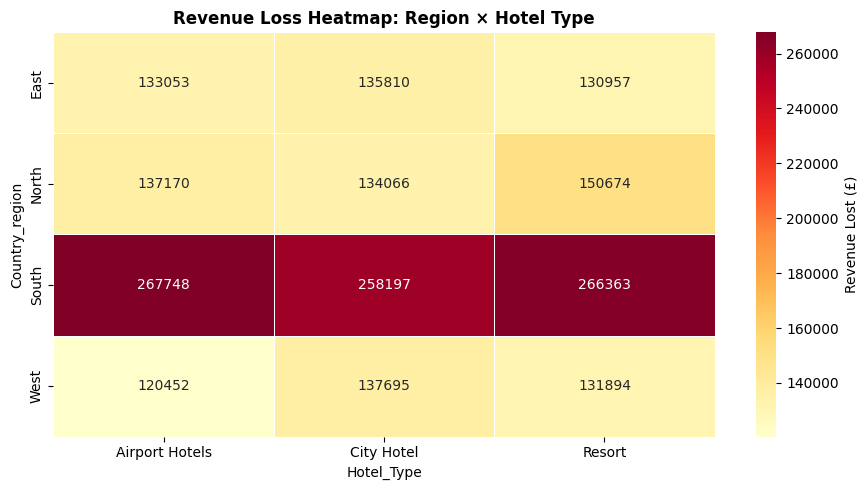

In [153]:
#  Heatmap: Region × Hotel Type revenue loss
pivot_region_hotel = lost.pivot_table(
    values='Revenue', index='Country_region',
    columns='Hotel_Type', aggfunc='sum', fill_value=0
)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_region_hotel, annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Revenue Lost (£)'})
plt.title('Revenue Loss Heatmap: Region × Hotel Type', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# **One-Hot encoded for categorical variables**

In [154]:
categorical_cols = [
    'Gender',
    'Ethnicity',
    'Educational_Level',
    'Income',
    'Country_region',
    'Hotel_Type',
    'Meal_Type',
    'Deposit_type',
    'Booking_channel'
]

# One-hot encode datasets
train_encoded = pd.get_dummies(Historical_train, columns=categorical_cols, drop_first=True, dtype='uint8')
valid_encoded = pd.get_dummies(valid, columns=categorical_cols, drop_first=True, dtype='uint8')
test_encoded = pd.get_dummies(test, columns=categorical_cols, drop_first=True, dtype='uint8')


# Columns used for model training (exclude target)
feature_cols = train_encoded.drop(columns=['Reservation_Status']).columns

# Align validation dataset
valid_encoded = valid_encoded.reindex(
    columns=train_encoded.columns,
    fill_value=0
)

# Align test dataset (no Reservation_Status)
test_encoded = test_encoded.reindex(
    columns=feature_cols,
    fill_value=0
)


print("Shape of train_encoded:", train_encoded.shape)
print("Shape of valid_encoded:", valid_encoded.shape)
print("Shape of test_encoded:", test_encoded.shape)

display(train_encoded.head())
display(valid_encoded.head())
display(test_encoded.head())



Shape of train_encoded: (27491, 38)
Shape of valid_encoded: (2749, 38)
Shape of test_encoded: (4318, 37)


,Reservation_id,Age,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Required_Car_Parking,Reservation_Status,Use_Promotion,...,Country_region_South,Country_region_West,Hotel_Type_City Hotel,Hotel_Type_Resort,Meal_Type_FB,Meal_Type_HB,Deposit_type_Non-Refundable,Deposit_type_Refundable,Booking_channel_Direct,Booking_channel_Online
0,39428300,40,2,2,0,0,0,1,1,1,...,0,0,1,0,0,0,0,0,0,1
1,77491756,49,3,3,0,0,0,1,1,0,...,0,0,1,0,0,0,0,1,0,1
2,73747291,42,3,3,0,0,0,1,1,0,...,0,0,1,0,0,0,0,0,0,1
3,67301739,25,4,3,0,0,0,1,1,1,...,1,0,0,0,0,0,0,1,0,0
4,77222321,62,1,1,0,0,0,0,1,1,...,0,0,0,1,0,0,0,0,1,0


,Reservation_id,Age,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Required_Car_Parking,Reservation_Status,Use_Promotion,...,Country_region_South,Country_region_West,Hotel_Type_City Hotel,Hotel_Type_Resort,Meal_Type_FB,Meal_Type_HB,Deposit_type_Non-Refundable,Deposit_type_Refundable,Booking_channel_Direct,Booking_channel_Online
0,45716350,56,2,2,0,0,0,0,3,1,...,0,1,0,1,0,1,0,0,0,0
1,88857401,60,2,2,0,1,0,1,2,0,...,0,1,0,1,1,0,0,0,0,1
2,16074440,58,3,1,0,0,0,0,2,1,...,0,0,0,0,1,0,0,0,1,0
3,10992124,23,1,2,0,1,0,0,1,1,...,0,0,0,0,1,0,0,1,1,0
4,15934351,47,1,1,0,1,0,1,1,1,...,1,0,1,0,0,1,0,0,0,1


,Reservation_id,Age,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Required_Car_Parking,Use_Promotion,Discount_Rate,...,Country_region_South,Country_region_West,Hotel_Type_City Hotel,Hotel_Type_Resort,Meal_Type_FB,Meal_Type_HB,Deposit_type_Non-Refundable,Deposit_type_Refundable,Booking_channel_Direct,Booking_channel_Online
0,62931593,52,3,3,0,0,0,1,1,10,...,1,0,1,0,0,1,0,0,1,0
1,70586099,47,2,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,4230648,28,2,2,0,0,0,0,1,5,...,0,0,1,0,0,0,0,0,0,0
3,25192322,65,1,3,2,0,0,1,1,10,...,1,0,0,0,1,0,0,0,0,1
4,80931528,45,3,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,1,0,0


In [155]:
train_encoded.to_csv('/content/drive/MyDrive/Hotel Revenue Prediction GCW/train_encoded.csv', index=False)

In [156]:
test_encoded.to_csv('/content/drive/MyDrive/Hotel Revenue Prediction GCW/test_encoded.csv', index=False)

In [157]:
valid_encoded.to_csv('//content/drive/MyDrive/Hotel Revenue Prediction GCW/valid_encoded.csv', index=False)

In [158]:
train_encoded

,Reservation_id,Age,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Required_Car_Parking,Reservation_Status,Use_Promotion,...,Country_region_South,Country_region_West,Hotel_Type_City Hotel,Hotel_Type_Resort,Meal_Type_FB,Meal_Type_HB,Deposit_type_Non-Refundable,Deposit_type_Refundable,Booking_channel_Direct,Booking_channel_Online
0,39428300,40,2,2,0,0,0,1,1,1,...,0,0,1,0,0,0,0,0,0,1
1,77491756,49,3,3,0,0,0,1,1,0,...,0,0,1,0,0,0,0,1,0,1
2,73747291,42,3,3,0,0,0,1,1,0,...,0,0,1,0,0,0,0,0,0,1
3,67301739,25,4,3,0,0,0,1,1,1,...,1,0,0,0,0,0,0,1,0,0
4,77222321,62,1,1,0,0,0,0,1,1,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27494,15645505,49,1,2,1,1,1,1,1,1,...,0,1,1,0,0,1,0,0,0,1
27495,56414525,49,2,1,0,0,0,1,3,1,...,1,0,0,0,0,0,0,1,0,0
27496,52023375,49,2,1,1,0,0,1,1,1,...,1,0,0,0,0,1,0,0,1,0
27497,98041387,65,3,2,0,0,0,0,2,1,...,1,0,0,0,1,0,0,0,0,1


In [159]:
train_encoded.dtypes

,0
Reservation_id,int64
Age,int64
Adults,int64
Children,int64
Babies,int64
Visted_Previously,int64
Previous_Cancellations,int64
Required_Car_Parking,int64
Reservation_Status,int64
Use_Promotion,int64


In [160]:
test_encoded

,Reservation_id,Age,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Required_Car_Parking,Use_Promotion,Discount_Rate,...,Country_region_South,Country_region_West,Hotel_Type_City Hotel,Hotel_Type_Resort,Meal_Type_FB,Meal_Type_HB,Deposit_type_Non-Refundable,Deposit_type_Refundable,Booking_channel_Direct,Booking_channel_Online
0,62931593,52,3,3,0,0,0,1,1,10,...,1,0,1,0,0,1,0,0,1,0
1,70586099,47,2,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,4230648,28,2,2,0,0,0,0,1,5,...,0,0,1,0,0,0,0,0,0,0
3,25192322,65,1,3,2,0,0,1,1,10,...,1,0,0,0,1,0,0,0,0,1
4,80931528,45,3,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4313,39110574,53,3,3,1,1,0,1,0,0,...,1,0,0,1,1,0,1,0,0,1
4314,5496554,63,3,3,0,0,0,1,1,40,...,1,0,0,1,0,1,0,1,0,0
4315,59004046,59,2,3,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
4316,65838682,43,4,2,1,0,0,1,0,0,...,0,1,0,1,0,0,0,0,0,1


In [161]:
test_encoded.dtypes

,0
Reservation_id,int64
Age,int64
Adults,int64
Children,int64
Babies,int64
Visted_Previously,int64
Previous_Cancellations,int64
Required_Car_Parking,int64
Use_Promotion,int64
Discount_Rate,int64


In [162]:
valid_encoded

,Reservation_id,Age,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Required_Car_Parking,Reservation_Status,Use_Promotion,...,Country_region_South,Country_region_West,Hotel_Type_City Hotel,Hotel_Type_Resort,Meal_Type_FB,Meal_Type_HB,Deposit_type_Non-Refundable,Deposit_type_Refundable,Booking_channel_Direct,Booking_channel_Online
0,45716350,56,2,2,0,0,0,0,3,1,...,0,1,0,1,0,1,0,0,0,0
1,88857401,60,2,2,0,1,0,1,2,0,...,0,1,0,1,1,0,0,0,0,1
2,16074440,58,3,1,0,0,0,0,2,1,...,0,0,0,0,1,0,0,0,1,0
3,10992124,23,1,2,0,1,0,0,1,1,...,0,0,0,0,1,0,0,1,1,0
4,15934351,47,1,1,0,1,0,1,1,1,...,1,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2744,32194836,22,5,1,1,1,0,0,1,1,...,1,0,0,1,0,0,0,1,0,1
2745,52215692,35,3,2,0,0,0,1,2,1,...,1,0,0,0,1,0,1,0,1,0
2746,31908733,18,2,3,0,0,0,0,3,1,...,0,0,0,1,1,0,0,1,0,0
2747,41776403,42,5,1,0,1,1,1,1,1,...,0,1,1,0,0,1,0,0,0,1


In [163]:
valid_encoded.dtypes

,0
Reservation_id,int64
Age,int64
Adults,int64
Children,int64
Babies,int64
Visted_Previously,int64
Previous_Cancellations,int64
Required_Car_Parking,int64
Reservation_Status,int64
Use_Promotion,int64
